# Load cleaned benchmark results

In [1]:
import os
import glob
import numpy as np
import pandas as pd
from datetime import datetime, date, timedelta
from typing import Tuple, Dict

def _parse_task_key_from_filename(fname: str) -> Tuple[str, str]:
    """
    Returns (source, task_key)
    source in {'internal','external'}.
    task_key is best-effort original identifier (internal keeps dots; external replaces _ -> space).
    """
    base = os.path.basename(fname)
    if base.startswith("internal_") and base.endswith("_matrix.csv"):
        key = base[len("internal_"):-len("_matrix.csv")]
        return "internal", key  # internal task paths were preserved (dots)
    if base.startswith("external_") and base.endswith("_matrix.csv"):
        key = base[len("external_"):-len("_matrix.csv")]
        # best-effort reverse of safe_task_name: underscores usually replaced spaces
        task = key.replace("_", " ")
        return "external", task
    return "unknown", base

def load_matrices_from_dir(dirpath: str = "benchmark_matrices_csv") -> Tuple[dict, dict]:
    """
    Load all CSV matrices in dirpath and rebuild two dictionaries:
      - internal_matrices: {task_key: {...same structure...}}
      - external_matrices: {task_key: {...}}
    Each entry contains:
      'data' (list of dicts), 'df_long' (pd.DataFrame), 'df_wide' (pd.DataFrame),
      'scorers' (empty list), 'n_observations', 'n_models', 'n_dates', 'n_scorers', 'density'
    """
    internal = {}
    external = {}

    pattern = os.path.join(dirpath, "*.csv")
    for fp in sorted(glob.glob(pattern)):
        source, task_key = _parse_task_key_from_filename(fp)
        if source == "unknown" or "public" in task_key:
            # skip unexpected files and public benchmarks
            continue

        # read wide CSV; first column is the date index labeled 'date' (export used index_label='date')
        try:
            df_wide = pd.read_csv(fp, index_col=0, parse_dates=True)
        except Exception:
            # fallback: read without parse_dates
            df_wide = pd.read_csv(fp, index_col=0)
            try:
                df_wide.index = pd.to_datetime(df_wide.index)
            except Exception:
                pass

        # parse index once (coerce errors), keep original df_wide for metrics
        df_wide.index = pd.to_datetime(df_wide.index, errors="coerce")
        df_wide_orig = df_wide.copy()

        # reset index to a column then melt into long form
        tmp = df_wide_orig.reset_index()
        idx_col = tmp.columns[0]  # usually the date column created by reset0ndex()
        df_long = (
            tmp.melt(id_vars=[idx_col], var_name="model_id", value_name="avg_score")
               .dropna(subset=["avg_score"])
               .rename(columns={idx_col: "date"})[["date", "model_id", "avg_score"]]
        )

        # convert date column to python date (safe conversion)
        df_long["date"] = pd.to_datetime(df_long["date"], errors="coerce").dt.date

        # data_rows list-of-dicts
        data_rows = df_long.to_dict(orient="records")

        # metrics
        n_dates = df_wide.shape[0]
        n_models = df_wide.shape[1]
        n_observations = len(df_long)
        non_null = df_wide.notna().sum().sum()
        density = non_null / (n_dates * n_models) if n_dates * n_models > 0 else 0

        entry = {
            "data": data_rows,
            "df_long": df_long,
            "df_wide": df_wide,
            "scorers": [],            # lost at export
            "n_observations": n_observations,
            "n_models": n_models,
            "n_dates": n_dates,
            "n_scorers": 0,           # unknown
            "density": density
        }

        if source == "internal":
            internal[task_key] = entry
        else:
            external[task_key] = entry

    return internal, external

if __name__ == "__main__":
    internal_matrices, external_matrices = load_matrices_from_dir("benchmark_matrices_csv")

    # Quick summary print
    def _summary(m, name):
        print(f"\n{name} - {len(m)} tasks")
        for i, (task, data) in enumerate(list(m.items())[:10]):
            print(f"  {i+1}. {task}: dates={data['n_dates']} models={data['n_models']} obs={data['n_observations']} density={data['density']:.2%}")

    _summary(internal_matrices, "Internal")
    _summary(external_matrices, "External")


Internal - 6 tasks
  1. bench.task.frontiermath.frontiermath_2025_02_28_private: dates=30 models=56 obs=56 density=3.33%
  2. bench.task.frontiermath.frontiermath_tier_4_2025_07_01_private: dates=16 models=25 obs=25 density=6.25%
  3. bench.task.gpqa.gpqa_diamond: dates=79 models=127 obs=127 density=1.27%
  4. bench.task.hendrycks_math.hendrycks_math_lvl_5: dates=68 models=109 obs=109 density=1.47%
  5. bench.task.otis_mock_aime.otis_mock_aime_24_25: dates=59 models=99 obs=99 density=1.69%
  6. bench.task.swe_bench.swe_bench_verified: dates=18 models=24 obs=24 density=5.56%

External - 36 tasks
  1. ARC AGI: dates=19 models=48 obs=48 density=5.26%
  2. ARC AI2: dates=52 models=75 obs=75 density=1.92%
  3. Adversarial NLI: dates=9 models=11 obs=11 density=11.11%
  4. Aider polyglot: dates=42 models=58 obs=58 density=2.38%
  5. BBH: dates=32 models=47 obs=47 density=3.12%
  6. Balrog: dates=17 models=27 obs=27 density=5.88%
  7. BoolQ: dates=48 models=63 obs=63 density=2.08%
  8. CadEva

In [2]:
def load_benchmark_lower_bounds(filepath: str = "benchmarks_lower_bounds.csv") -> dict:
    """
    Load benchmark lower bounds (random-chance baselines) from CSV.
    
    Expected format:
    Benchmark;Lower bound;Concise reason;Source URL
    WinoGrande;50%;Binary fill-in-the-blank;https://...
    
    Args:
        filepath: path to CSV file with lower bounds
    
    Returns:
        Dictionary mapping benchmark names to lower bound values (as floats)
    """
    lower_bounds = {}
    
    try:
        # Read CSV - don't force dtype=str to allow pandas to handle NA properly
        df = pd.read_csv(filepath, sep=';')
        
        for _, row in df.iterrows():
            # Skip rows with missing benchmark name
            if pd.isna(row['Benchmark']):
                continue
                
            benchmark_name = str(row['Benchmark']).strip()
            raw_val = row['Lower bound']
            
            # If missing, store NaN
            if pd.isna(raw_val):
                lower_bounds[benchmark_name] = np.nan
                print(f"  {benchmark_name}: NA (missing)")
                continue
            
            lower_bound_str = str(raw_val).strip().rstrip('%')
            lower_bound_str = lower_bound_str.replace(',', '.')  # handle European decimal
            
            # Treat common empty markers as missing
            if lower_bound_str.lower() in {'', 'nan', 'na', 'none', '-'}:
                lower_bounds[benchmark_name] = np.nan
                print(f"  {benchmark_name}: NA (missing)")
                continue

            try:
                # Convert percentage to decimal (e.g., "50%" -> 0.5)
                lower_bound_value = float(lower_bound_str) / 100
                lower_bounds[benchmark_name] = lower_bound_value
                print(f"  {benchmark_name}: {lower_bound_value:.1%}")
            except ValueError:
                print(f"  Warning: Could not parse '{lower_bound_str}' for {benchmark_name}")
        
        print(f"\nSuccessfully loaded {len(lower_bounds)} benchmark lower bounds")
        return lower_bounds
    
    except FileNotFoundError:
        print(f"Warning: Lower bounds file not found at {filepath}")
        return {}
    except Exception as e:
        print(f"Error loading lower bounds: {e}")
        import traceback
        traceback.print_exc()
        return {}

# Load the lower bounds
print("Loading benchmark lower bounds...")
lower_bounds_dict = load_benchmark_lower_bounds("benchmarks_lower_bounds.csv")

Loading benchmark lower bounds...
  bench.task.frontiermath.frontiermath_2025_02_28_private: 0.0%
  bench.task.frontiermath.frontiermath_tier_4_2025_07_01_private: 0.0%
  bench.task.gpqa.gpqa_diamond: 25.0%
  GPQA-Diamond: 25.0%
  bench.task.hendrycks_math.hendrycks_math_lvl_5: 0.0%
  bench.task.otis_mock_aime.otis_mock_aime_24_25: 0.1%
  bench.task.swe_bench.swe_bench_verified: 0.0%
  Aider polyglot: 0.0%
  Balrog: 0.0%
  DeepResearch Bench: NA (missing)
  Factorio Learning Environment: 0.0%
  Fiction.LiveBench: NA (missing)
  GeoBench: NA (missing)
  GSO-Bench: 0.0%
  SimpleBench: 16.6%
  Terminal Bench: 0.0%
  VPCT: 33.3%
  WeirdML V2: 0.0%
  Adversarial NLI: 33.3%
  ARC AI2: 25.0%
  ARC AGI: 0.0%
  BBH: 25.0%
  BoolQ: 50.0%
  CadEval: 0.0%
  Cybench: 0.0%
  GSM8K: 0.0%
  HellaSwag: 25.0%
  LAMBADA: 0.0%
  Lech Mazur Writing: NA (missing)
  LiveBench: NA (missing)
  MMLU: 25.0%
  OpenBookQA: 25.0%
  OS World (Screenshot): 0.0%
  OSUniverse: 0.0%
  PIQA: 50.0%
  ScienceQA: 39.8%
  Su

In [3]:
# ============================================================================
# CHECK BENCHMARK NAMES AGAINST LOWER BOUNDS
# ============================================================================

# Load matrices if not already loaded
internal_matrices, external_matrices = load_matrices_from_dir("benchmark_matrices_csv")

# Combine all benchmark names
all_benchmark_names = set(list(internal_matrices.keys()) + list(external_matrices.keys()))

print(f"\n{'='*80}")
print("BENCHMARK NAME MATCHING ANALYSIS")
print(f"{'='*80}")
print(f"Total benchmarks in data: {len(all_benchmark_names)}")
print(f"Total benchmarks with lower bounds: {len(lower_bounds_dict)}")

# Find benchmarks without lower bounds
benchmarks_without_bounds = all_benchmark_names - set(lower_bounds_dict.keys())
benchmarks_with_bounds = all_benchmark_names & set(lower_bounds_dict.keys())

print(f"\n{'='*80}")
print(f"BENCHMARKS WITH LOWER BOUNDS ({len(benchmarks_with_bounds)})")
print(f"{'='*80}")
for name in sorted(benchmarks_with_bounds):
    bound = lower_bounds_dict[name]
    print(f"  ✓ {name}: {bound:.1%}")

print(f"\n{'='*80}")
print(f"BENCHMARKS WITHOUT LOWER BOUNDS ({len(benchmarks_without_bounds)})")
print(f"{'='*80}")
for name in sorted(benchmarks_without_bounds):
    # Try to find potential matches in lower_bounds_dict
    potential_matches = []
    name_lower = name.lower().replace('_', ' ').replace('-', ' ')
    
    for bound_name in lower_bounds_dict.keys():
        bound_name_lower = bound_name.lower().replace('_', ' ').replace('-', ' ')
        
        # Check for partial matches
        if bound_name_lower in name_lower or name_lower in bound_name_lower:
            potential_matches.append(bound_name)
        # Check for word overlap
        name_words = set(name_lower.split())
        bound_words = set(bound_name_lower.split())
        overlap = name_words & bound_words
        if len(overlap) >= 2:  # At least 2 words in common
            if bound_name not in potential_matches:
                potential_matches.append(bound_name)
    
    if potential_matches:
        print(f"  ✗ {name}")
        for match in potential_matches:
            print(f"      → Possible match: {match} ({lower_bounds_dict[match]:.1%})")
    else:
        print(f"  ✗ {name}")

# Also check for unused lower bounds
unused_bounds = set(lower_bounds_dict.keys()) - all_benchmark_names
if unused_bounds:
    print(f"\n{'='*80}")
    print(f"LOWER BOUNDS WITHOUT MATCHING BENCHMARKS ({len(unused_bounds)})")
    print(f"{'='*80}")
    for name in sorted(unused_bounds):
        bound = lower_bounds_dict[name]
        print(f"  ? {name}: {bound:.1%}")
        
        # Try to find potential matches in benchmark data
        potential_matches = []
        name_lower = name.lower().replace('_', ' ').replace('-', ' ')
        
        for bench_name in all_benchmark_names:
            bench_lower = bench_name.lower().replace('_', ' ').replace('-', ' ')
            
            if bench_lower in name_lower or name_lower in bench_lower:
                potential_matches.append(bench_name)
            
            name_words = set(name_lower.split())
            bench_words = set(bench_lower.split())
            overlap = name_words & bench_words
            if len(overlap) >= 2:
                if bench_name not in potential_matches:
                    potential_matches.append(bench_name)
        
        if potential_matches:
            for match in potential_matches:
                print(f"      → Possible match: {match}")

# Create a mapping suggestion dictionary
print(f"\n{'='*80}")
print("SUGGESTED MAPPING (copy to lower bounds CSV)")
print(f"{'='*80}")

for bench_name in sorted(benchmarks_without_bounds):
    print(f"{bench_name};[NEEDS VALUE];[REASON];[URL]")


BENCHMARK NAME MATCHING ANALYSIS
Total benchmarks in data: 42
Total benchmarks with lower bounds: 45

BENCHMARKS WITH LOWER BOUNDS (42)
  ✓ ARC AGI: 0.0%
  ✓ ARC AI2: 25.0%
  ✓ Adversarial NLI: 33.3%
  ✓ Aider polyglot: 0.0%
  ✓ BBH: 25.0%
  ✓ Balrog: 0.0%
  ✓ BoolQ: 50.0%
  ✓ CadEval: 0.0%
  ✓ CommonSenseQA 2: 50.0%
  ✓ Cybench: 0.0%
  ✓ DeepResearch Bench: nan%
  ✓ EnigmaEval: 0.0%
  ✓ Fiction.LiveBench: nan%
  ✓ GSM8K: 0.0%
  ✓ GSO-Bench: 0.0%
  ✓ HellaSwag: 25.0%
  ✓ LAMBADA: 0.0%
  ✓ Lech Mazur Writing: nan%
  ✓ LiveBench: nan%
  ✓ MMLU: 25.0%
  ✓ OS World (Screenshot): 0.0%
  ✓ OSUniverse: 0.0%
  ✓ OpenBookQA: 25.0%
  ✓ PIQA: 50.0%
  ✓ ScienceQA: 39.8%
  ✓ SimpleBench: 16.6%
  ✓ SuperGlue: 44.3%
  ✓ Terminal Bench: 0.0%
  ✓ The Agent Company: 0.0%
  ✓ ToolComp: 0.0%
  ✓ TriviaQA: 12.7%
  ✓ VISTA: nan%
  ✓ VPCT: 33.3%
  ✓ VideoMME: 25.0%
  ✓ WeirdML V2: 0.0%
  ✓ WinoGrande: 50.0%
  ✓ bench.task.frontiermath.frontiermath_2025_02_28_private: 0.0%
  ✓ bench.task.frontiermath.frontie

# PyMC Harvey forecast

In [4]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import pickle

# Forecast parameters
n_samples     = 2000
n_tune        = 1000
top_n         = 3
forecast_days = 1523
forecast_type = "independent"  # Type of forecast model

# Create output directories
os.makedirs('Images', exist_ok=True)
os.makedirs('Fits', exist_ok=True)

# ============================================================================
# HARVEY FUNCTION IMPLEMENTATIONS
# ============================================================================

def harvey_curve(t, L, r, t0, alpha):
    """
    Harvey growth function: L * [1 - (1-α) * exp(-r*(t-t0))]^(1/(1-α))
    
    Args:
        t: time (numeric)
        L: asymptote (maximum value)
        r: growth rate
        t0: time offset
        alpha: shape parameter (must be > 1 for proper growth curve)
    
    Note: For α > 1, this gives an S-shaped curve that accelerates then decelerates
    """
    base = 1 - (1 - alpha) * pm.math.exp(-r * (t - t0))
    return L * base ** (1 / (1 - alpha))

def extract_frontier_improvements(df_long, top_n=1):
    """
    Extract frontier improvements from benchmark data.
    
    For top_n=1: tracks the absolute best score over time (frontier).
    For top_n>1: tracks models that were in top-N at their release date.
    
    Ranking logic:
    - Sort by score (descending), then by first_date (ascending), then by model_id
    - Models with the same score get the same rank
    
    Args:
        df_long: DataFrame with columns [date, model_id, avg_score]
        top_n: number of top models to track
    
    Returns:
        List of dicts with keys: date, score, model_id, rank
    """
    df_sorted = df_long.sort_values('date')
    frontier_improvements = []
    
    if top_n == 1:
        # Original frontier logic (best score over time)
        best_score = float('-inf')
        
        for _, row in df_sorted.iterrows():
            if row['avg_score'] > best_score:
                best_score = row['avg_score']
                frontier_improvements.append({
                    'date': row['date'],
                    'score': row['avg_score'],
                    'model_id': row['model_id'],
                    'rank': 1
                })
    else:
        # Track models that were in top-N at their release date
        for release_date in df_sorted['date'].unique():
            # Models released on this date
            released_today = df_sorted[df_sorted['date'] == release_date].copy()
            
            # Historical scores (BEFORE today)
            historical_scores = df_sorted[df_sorted['date'] < release_date].copy()
            
            if len(historical_scores) == 0:
                # First date: rank models among themselves
                released_sorted = released_today.sort_values(
                    ['avg_score', 'model_id'], 
                    ascending=[False, True]
                )
                
                # Assign ranks (same score = same rank)
                prev_score = None
                current_rank = 0
                actual_rank = 0
                
                for _, row in released_sorted.iterrows():
                    actual_rank += 1
                    if row['avg_score'] != prev_score:
                        current_rank = actual_rank
                        prev_score = row['avg_score']
                    
                    if current_rank <= top_n:
                        frontier_improvements.append({
                            'date': row['date'],
                            'score': row['avg_score'],
                            'model_id': row['model_id'],
                            'rank': current_rank
                        })
            else:
                # Get the best scores BEFORE today
                best_before_today = historical_scores.groupby('model_id')['avg_score'].max().reset_index()
                best_before_today = best_before_today.nlargest(top_n, 'avg_score')
                top_n_threshold = best_before_today['avg_score'].min()
                
                # Check which newly released models made it into top-N
                for _, row in released_today.iterrows():
                    if row['avg_score'] >= top_n_threshold:
                        # Calculate rank among ALL models up to and including today
                        all_scores_now = df_sorted[df_sorted['date'] <= release_date].copy()
                        best_at_date = all_scores_now.groupby('model_id')['avg_score'].max().reset_index()
                        
                        # Get earliest date for each model at their best score
                        earliest_dates = all_scores_now.loc[
                            all_scores_now.groupby('model_id')['avg_score'].idxmax()
                        ][['model_id', 'date']].rename(columns={'date': 'first_date'})
                        
                        best_at_date = best_at_date.merge(earliest_dates, on='model_id')
                        
                        # Sort: score (desc), date (asc), model_id (asc)
                        best_at_date = best_at_date.sort_values(
                            ['avg_score', 'first_date', 'model_id'], 
                            ascending=[False, True, True]
                        )
                        
                        # Calculate rank: count models with STRICTLY higher scores
                        # Models with same score get the same rank
                        rank = (best_at_date['avg_score'] > row['avg_score']).sum() + 1
                        
                        # Only include if rank is within top_n
                        if rank <= top_n:
                            frontier_improvements.append({
                                'date': row['date'],
                                'score': row['avg_score'],
                                'model_id': row['model_id'],
                                'rank': rank
                            })
    
    return frontier_improvements

def fit_harvey_benchmark(df_long, task_name, n_samples=2000, n_tune=1000, top_n=3, 
                         forecast_type="harvey_independent", save_dir='Fits', 
                         lower_bounds_dict=None):
    """
    Fit a Harvey curve to benchmark data.
    
    Args:
        df_long: DataFrame with columns [date, model_id, avg_score]
        task_name: name of the benchmark (for plotting)
        n_samples: number of MCMC samples
        n_tune: number of tuning steps
        top_n: number of top models to track (1 = frontier only)
        forecast_type: type of forecast model
        save_dir: directory to save inference data
        lower_bounds_dict: dict mapping benchmark names to lower bounds (0-1 scale)
    
    Returns:
        idata: InferenceData object with posterior samples
        frontier_df: DataFrame with frontier/top-N improvements
        model: PyMC model object
    """
    # Extract frontier improvements
    frontier_improvements = extract_frontier_improvements(df_long, top_n=top_n)
    
    frontier_df = pd.DataFrame(frontier_improvements)
    frontier_df['date_dt'] = pd.to_datetime(frontier_df['date'])
    min_date = frontier_df['date_dt'].min()
    frontier_df['days'] = (frontier_df['date_dt'] - min_date).dt.days
    
    # Prepare data for PyMC
    t_obs = frontier_df['days'].values.astype(float)
    y_obs = frontier_df['score'].values.astype(float)
    
    # Get lower bound
    if lower_bounds_dict is not None and task_name in lower_bounds_dict:
        lower_bound = lower_bounds_dict[task_name]
        if pd.isna(lower_bound):
            lower_bound = 0.0
            print(f"  Lower bound for {task_name}: NA (using 0.0)")
        else:
            print(f"  Lower bound for {task_name}: {lower_bound:.1%}")
    else:
        lower_bound = 0.0
        print(f"  Lower bound for {task_name}: not found (using 0.0)")

    # Build PyMC model with SHIFTED HARVEY
    with pm.Model() as model:
        # Priors
        available_range = 1.0 - lower_bound
        
        # L: upper asymptote
        target_L_abs = 0.95
        beta_mean = (target_L_abs - lower_bound) / available_range
        beta_mean = np.clip(beta_mean, 0.0, 0.99)
        
        L_raw = pm.Beta('L_raw', mu=beta_mean, sigma=0.05)
        L = pm.Deterministic('L', lower_bound + available_range * L_raw)
        
        # r: growth rate (similar range to logistic k)
        r = pm.Gamma('r', mu=0.01, sigma=0.008)
        
        # t0: time offset (should be before or at first observation)
        t_mid = (t_obs.min() + t_obs.max()) / 2
        t0 = pm.Gumbel('t0', mu=t_mid, beta=365*2)

        # alpha: shape parameter (must be > 1 for growth curve)
        # Converges to logistic for alpha = 2
        alpha_harvey_base = pm.Gamma('alpha_harvey_base', mu=1.0, sigma=0.5)
        alpha_harvey = pm.Deterministic('alpha_harvey', alpha_harvey_base + 1.0)  # Ensure > 1
        
        # Expected value: SHIFTED HARVEY
        exponent = -r * (t_obs - t0)
        base = 1 - (1 - alpha_harvey) * pm.math.exp(exponent)
        # Log-space for numerical stability:
        log_harvey = (1 / (1 - alpha_harvey)) * pm.math.log(base)
        harvey_01 = pm.math.exp(log_harvey)
        
        mu = lower_bound + (L - lower_bound) * harvey_01
        
        # Heteroskedastic noise (same as logistic)
        sigma_base = pm.Gamma('sigma_base', mu=0.05 + top_n/100, sigma=0.035 + top_n/200)
        
        variance_shape = pm.math.sqrt((mu - lower_bound) * (L - mu))
        max_variance = (L - lower_bound) / 2.0
        noise_factor = variance_shape / max_variance
        
        alpha_skew = pm.TruncatedNormal('alpha_skew', mu=-1.5 - top_n/2, sigma=0.375 + top_n/8, upper=0)
        
        # Likelihood
        y = pm.SkewNormal('y', mu=mu, sigma=0.01 + sigma_base * noise_factor, alpha=alpha_skew, observed=y_obs)
        
        # Sample
        idata = pm.sample(n_samples, tune=n_tune, return_inferencedata=True,
                         target_accept=0.95, random_seed=42, progressbar=False)
    
    # Save results
    safe_task_name = task_name.replace('/', '_').replace(' ', '_').replace('.', '_')
    
    idata_path = os.path.join(save_dir, f'{safe_task_name}_{forecast_type}_top{top_n}_idata.nc')
    idata.to_netcdf(idata_path)
    print(f"Saved inference data to: {idata_path}")
    
    frontier_csv_path = os.path.join(save_dir, f'{safe_task_name}_{forecast_type}_top{top_n}_frontier.csv')
    frontier_df.to_csv(frontier_csv_path, index=False)
    print(f"Saved frontier data to: {frontier_csv_path}")
    
    metadata = {
        'task_name': task_name,
        'top_n': top_n,
        'forecast_type': forecast_type,
        'n_samples': n_samples,
        'n_tune': n_tune,
        'idata_path': idata_path,
        'frontier_csv_path': frontier_csv_path,
        'heteroskedastic': True,
        'noise_model': 'beta_like',
        'lower_bound': lower_bound,
        'curve_type': 'harvey'
    }
    metadata_path = os.path.join(save_dir, f'{safe_task_name}_{forecast_type}_top{top_n}_metadata.pkl')
    with open(metadata_path, 'wb') as f:
        pickle.dump(metadata, f)
    print(f"Saved metadata to: {metadata_path}")
    
    return idata, frontier_df, model

def plot_harvey_fit(idata, frontier_df, task_name, forecast_days=1523, top_n=3, 
                    forecast_type="harvey_independent", save_dir='Images', lower_bound=0.0):
    """
    Plot the Harvey fit with uncertainty bands.
    
    Args:
        idata: InferenceData from PyMC sampling
        frontier_df: DataFrame with frontier data and 'days' column
        task_name: name of the benchmark
        forecast_days: number of days to forecast beyond last observation
        top_n: number of top models tracked
        forecast_type: type of forecast model
        save_dir: directory to save plots
        lower_bound: lower asymptote (random chance baseline)
    """
    # Extract posterior samples
    posterior = idata.posterior
    L_samples = posterior['L'].values.flatten()
    r_samples = posterior['r'].values.flatten()
    t0_samples = posterior['t0'].values.flatten()
    alpha_samples = posterior['alpha_harvey'].values.flatten()
    sigma_base_samples = posterior['sigma_base'].values.flatten()
    alpha_skew_samples = posterior['alpha_skew'].values.flatten()
    
    # Time grid
    t_obs = frontier_df['days'].values
    t_min = t_obs.min()
    t_max = t_obs.max() + forecast_days
    t_grid = np.linspace(t_min, t_max, 200)
    
    # Calculate predictions for each posterior sample
    n_samples = len(L_samples)
    predictions = np.zeros((n_samples, len(t_grid)))
    sigma_obs_grid = np.zeros((n_samples, len(t_grid)))
    
    for i in range(n_samples):
        # Harvey curve
        exponent = -r_samples[i] * (t_grid - t0_samples[i])
        base = 1 - (1 - alpha_samples[i]) * np.exp(exponent)
        base = np.maximum(base, 1e-10)
        harvey_01 = np.power(base, 1 / (1 - alpha_samples[i]))
        
        mu_i = lower_bound + (L_samples[i] - lower_bound) * harvey_01
        predictions[i] = mu_i
        
        # Heteroskedastic sigma
        variance_shape = np.sqrt((mu_i - lower_bound) * (L_samples[i] - mu_i))
        max_variance = (L_samples[i] - lower_bound) / 2.0
        noise_factor = variance_shape / max_variance
        sigma_obs_grid[i] = 0.01 + sigma_base_samples[i] * noise_factor
    
    # Calculate percentiles
    median_pred = np.percentile(predictions, 50, axis=0)
    lower_50 = np.percentile(predictions, 25, axis=0)
    upper_50 = np.percentile(predictions, 75, axis=0)
    lower_95 = np.percentile(predictions, 2.5, axis=0)
    upper_95 = np.percentile(predictions, 97.5, axis=0)
    
    # Prediction intervals with observation noise
    from scipy.stats import skewnorm
    subsample_idx = np.arange(0, n_samples, 5)
    lower_95_sampling = np.zeros(len(t_grid))
    upper_95_sampling = np.zeros(len(t_grid))
    n_draws_per_posterior = 5
    
    for j in range(len(t_grid)):
        all_samples = []
        for idx in subsample_idx:
            mu_t = predictions[idx, j]
            sigma_t = sigma_obs_grid[idx, j]
            alpha_t = alpha_skew_samples[idx]
            samples = skewnorm.rvs(alpha_t, loc=mu_t, scale=sigma_t, size=n_draws_per_posterior)
            all_samples.extend(samples)
        
        all_samples = np.clip(all_samples, 0, 1)
        lower_95_sampling[j] = np.percentile(all_samples, 2.5)
        upper_95_sampling[j] = np.percentile(all_samples, 97.5)
    
    # Convert to dates
    min_date = frontier_df['date'].min()
    dates_grid = [min_date + timedelta(days=int(d)) for d in t_grid]
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if lower_bound > 0.01:
        ax.axhline(lower_bound, color='gray', linestyle=':', alpha=0.5, linewidth=1.5, 
                  label=f'Random chance ({lower_bound:.1%})')
    
    ax.fill_between(dates_grid, lower_95_sampling, upper_95_sampling, 
                    alpha=0.1, color='#F18F01', label='95% prediction interval')
    ax.fill_between(dates_grid, lower_95, upper_95, 
                    alpha=0.2, color='#2E86AB', label='95% CI (Harvey)')
    ax.fill_between(dates_grid, lower_50, upper_50, 
                    alpha=0.3, color='#2E86AB', label='50% CI (Harvey)')
    ax.plot(dates_grid, median_pred, '-', linewidth=2, color='#2E86AB', label='Median prediction')
    
    if top_n == 1:
        ax.plot(frontier_df['date'], frontier_df['score'], 'o', markersize=8, 
               color='#A23B72', label='Observed frontier', zorder=10)
    else:
        colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, top_n))
        for rank in range(1, top_n + 1):
            rank_data = frontier_df[frontier_df['rank'] == rank]
            if not rank_data.empty:
                ax.plot(rank_data['date'], rank_data['score'], 'o', 
                       markersize=10 - (rank-1)*1.0,
                       color=colors[rank-1], 
                       label=f'Top-{rank} at release', 
                       alpha=0.8, zorder=10-rank)
    
    last_date = frontier_df['date'].max()
    ax.axvline(last_date, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(last_date, ax.get_ylim()[0] + 0.05, 'Last obs', 
           rotation=90, verticalalignment='bottom', fontsize=9, color='gray')
    
    ax.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    
    title_suffix = " (Frontier)" if top_n == 1 else f" (Top-{top_n} at release)"
    ax.set_title(f'Harvey Growth Forecast: {task_name}{title_suffix}', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_ylim(0, 1.05)
    
    import matplotlib.dates as mdates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    
    safe_task_name = task_name.replace('/', '_').replace(' ', '_').replace('.', '_')
    plot_path = os.path.join(save_dir, f'{safe_task_name}_{forecast_type}_top{top_n}_forecast.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Saved plot to: {plot_path}")
    plt.show()
    
    # Print summary
    print(f"\n{'='*80}")
    title_text = f"HARVEY FORECAST SUMMARY: {task_name} (Top-{top_n})" if top_n > 1 else f"HARVEY FORECAST SUMMARY: {task_name} (Frontier)"
    print(title_text)
    print(f"{'='*80}")
    print(f"Data points: {len(frontier_df)}")
    print(f"Unique models: {frontier_df['model_id'].nunique()}")
    print(f"Lower asymptote (random chance): {lower_bound:.3f}")
    print(f"Current best score: {frontier_df['score'].max():.3f}")
    print(f"Predicted upper asymptote (L): {np.median(L_samples):.3f} [{np.percentile(L_samples, 2.5):.3f}, {np.percentile(L_samples, 97.5):.3f}]")
    print(f"Growth rate (r): {np.median(r_samples):.4f} [{np.percentile(r_samples, 2.5):.4f}, {np.percentile(r_samples, 97.5):.4f}]")
    print(f"Time offset (t0): {np.median(t0_samples):.0f} days")
    print(f"Shape parameter (α): {np.median(alpha_samples):.2f} [{np.percentile(alpha_samples, 2.5):.2f}, {np.percentile(alpha_samples, 97.5):.2f}]")

## Internal Benchmarks

In [ ]:
# Run fit for all internal benchmarks
internal_matrices, external_matrices = load_matrices_from_dir("benchmark_matrices_csv")

print(f"Found {len(internal_matrices)} internal benchmarks")
print(f"Found {len(external_matrices)} external benchmarks")

# Fit Harvey models to internal benchmarks
results = {}

for task_name, data in internal_matrices.items():
    print(f"\n{'='*80}")
    print(f"Fitting: {task_name}")
    print(f"{'='*80}")
    
    df_long = data['df_long']
    
    if len(df_long) < 3:
        print(f"Skipping {task_name}: insufficient data ({len(df_long)} observations)")
        continue
    
    try:
        idata, frontier_df, model = fit_harvey_benchmark(
            df_long, task_name, 
            n_samples=n_samples,
            n_tune=n_tune,
            top_n=top_n,
            forecast_type="harvey_independent",
            lower_bounds_dict=lower_bounds_dict
        )
        
        # Get lower bound for plotting
        lower_bound = 0.0
        if lower_bounds_dict and task_name in lower_bounds_dict:
            lb = lower_bounds_dict[task_name]
            if not pd.isna(lb):
                lower_bound = lb
        
        results[task_name] = {
            'idata': idata,
            'frontier_df': frontier_df,
            'model': model
        }
        
        # Plot
        plot_harvey_fit(idata, frontier_df, task_name, 
                       forecast_days=forecast_days,
                       top_n=top_n,
                       forecast_type="harvey_independent",
                       lower_bound=lower_bound)
        
        # Print diagnostics
        print("\nMCMC Diagnostics:")
        print(az.summary(idata, var_names=['L', 'r', 't0', 'alpha_harvey', 'sigma_base', 'alpha_skew']))
        
    except Exception as e:
        print(f"Error fitting {task_name}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*80}")
print(f"Successfully fit {len(results)} / {len(internal_matrices)} internal benchmarks")
print(f"{'='*80}")

## External benchmarks

In [ ]:
# Fit Harvey models to external benchmarks
for task_name, data in external_matrices.items():
    print(f"\n{'='*80}")
    print(f"Fitting: {task_name}")
    print(f"{'='*80}")
    
    df_long = data['df_long']
    
    if len(df_long) < 3:
        print(f"Skipping {task_name}: insufficient data ({len(df_long)} observations)")
        continue
    
    try:
        idata, frontier_df, model = fit_harvey_benchmark(
            df_long, task_name,
            n_samples=n_samples,
            n_tune=n_tune,
            top_n=top_n,
            forecast_type="harvey_independent",
            lower_bounds_dict=lower_bounds_dict
        )
        
        # Get lower bound for plotting
        lower_bound = 0.0
        if lower_bounds_dict and task_name in lower_bounds_dict:
            lb = lower_bounds_dict[task_name]
            if not pd.isna(lb):
                lower_bound = lb
        
        results[task_name] = {
            'idata': idata,
            'frontier_df': frontier_df,
            'model': model
        }
        
        # Plot
        plot_harvey_fit(idata, frontier_df, task_name,
                       forecast_days=forecast_days,
                       top_n=top_n,
                       forecast_type="harvey_independent",
                       lower_bound=lower_bound)
        
        # Print diagnostics
        print("\nMCMC Diagnostics:")
        print(az.summary(idata, var_names=['L', 'r', 't0', 'alpha_harvey', 'sigma_base', 'alpha_skew']))
        
    except Exception as e:
        print(f"Error fitting {task_name}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*80}")
print(f"Successfully fit {len(results)} total benchmarks")
print(f"  - Internal: {sum(1 for k in results if k in internal_matrices)}")
print(f"  - External: {sum(1 for k in results if k in external_matrices)}")
print(f"{'='*80}")

# Joint hyperparameters

In [15]:
# ============================================================================
# JOINT HARVEY HYPERPARAMETER MODEL
# ============================================================================

def fit_harvey_joint_hyperparameters(benchmark_dict, n_samples=2000, n_tune=1000, 
                                     top_n=3, forecast_type="harvey_joint", 
                                     save_dir='Fits', lower_bounds_dict=None):
    """
    Fit Harvey curves to multiple benchmarks with shared hyperparameters.
    VECTORIZED VERSION - much faster compilation and sampling.
    
    Args:
        benchmark_dict: dict of {task_name: df_long} for multiple benchmarks
        n_samples: number of MCMC samples
        n_tune: number of tuning steps
        top_n: number of top models to track
        forecast_type: type of forecast model
        save_dir: directory to save inference data
        lower_bounds_dict: dict mapping benchmark names to lower bounds (0-1 scale)
    
    Returns:
        idata: InferenceData with posterior samples for all benchmarks
        frontier_dfs: dict of {task_name: frontier_df}
        model: PyMC model object
    """
    # Prepare data for all benchmarks
    task_names = []
    all_t_obs_list = []
    all_y_obs_list = []
    all_lower_bounds = []
    task_indices = []
    frontier_dfs = {}
    
    for task_idx, (task_name, df_long) in enumerate(benchmark_dict.items()):
        # Extract frontier (same logic as before)            
        frontier_improvements = extract_frontier_improvements(df_long, top_n=top_n)
        
        frontier_df = pd.DataFrame(frontier_improvements)
        frontier_df['date_dt'] = pd.to_datetime(frontier_df['date'])
        min_date = frontier_df['date_dt'].min()
        frontier_df['days'] = (frontier_df['date_dt'] - min_date).dt.days
        
        # Get lower bound
        if lower_bounds_dict is not None and task_name in lower_bounds_dict:
            lower_bound = lower_bounds_dict[task_name]
            if pd.isna(lower_bound):
                lower_bound = 0.0
                print(f"  Lower bound for {task_name}: NA (using 0.0)")
            else:
                print(f"  Lower bound for {task_name}: {lower_bound:.1%}")
        else:
            lower_bound = 0.0
            print(f"  Lower bound for {task_name}: not found (using 0.0)")
        
        frontier_dfs[task_name] = frontier_df
        task_names.append(task_name)
        all_lower_bounds.append(lower_bound)
        
        t_obs = frontier_df['days'].values.astype(float)
        y_obs = frontier_df['score'].values.astype(float)
        
        all_t_obs_list.append(t_obs)
        all_y_obs_list.append(y_obs)
        task_indices.extend([task_idx] * len(t_obs))
    
    n_tasks = len(task_names)
    task_indices = np.array(task_indices, dtype=np.int32)
    all_lower_bounds = np.array(all_lower_bounds)
    
    # Flatten observations for vectorized likelihood
    all_t_obs_flat = np.concatenate(all_t_obs_list)
    all_y_obs_flat = np.concatenate(all_y_obs_list)
    
    # Compute t_mids for each task
    t_mids = np.array([(all_t_obs_list[i].min() + all_t_obs_list[i].max()) / 2 
                       for i in range(n_tasks)])
    
    print(f"Fitting joint Harvey model with {n_tasks} benchmarks...")
    print(f"Total observations: {len(task_indices)}")
    
    # Build joint hierarchical Harvey model - VECTORIZED
    with pm.Model() as model:
        # ====================================================================
        # HYPERPRIORS (shared across all benchmarks)
        # ====================================================================
        
        # Asymptote (L) hyperparameters
        L_mu = pm.Beta('L_mu', mu=0.95, sigma=0.02)
        L_sigma = pm.HalfNormal('L_sigma', sigma=0.05)
        
        # Growth rate (r) hyperparameters
        r_mu = pm.Gamma('r_mu', mu=0.005, sigma=0.002)
        r_sigma = pm.HalfNormal('r_sigma', sigma=0.005)
        
        # Shape parameter (alpha) hyperparameters
        alpha_base_mu = pm.Gamma('alpha_base_mu', mu=1.5, sigma=0.5)
        alpha_base_sigma = pm.HalfNormal('alpha_base_sigma', sigma=0.5)
        
        # Base noise hyperparameters
        sigma_base_mu = pm.Gamma('sigma_base_mu', mu=0.05 + top_n/50, sigma=0.02)
        sigma_base_sigma = pm.HalfNormal('sigma_base_sigma', sigma=0.05)
        
        # Skewness hyperparameters
        alpha_skew_mu = pm.Normal('alpha_skew_mu', mu=-2 - top_n/2, sigma=0.5)
        alpha_skew_sigma = pm.HalfNormal('alpha_skew_sigma', sigma=1)
        
        # ====================================================================
        # TASK-SPECIFIC PARAMETERS
        # ====================================================================
        
        # Task-specific upper asymptotes (shifted)
        L_raw = pm.Beta('L_raw', mu=L_mu, sigma=L_sigma, shape=n_tasks)
        lower_bounds_tensor = pm.math.constant(all_lower_bounds)
        available_range = 1.0 - lower_bounds_tensor
        L_upper = pm.Deterministic('L_upper', lower_bounds_tensor + available_range * L_raw)
        
        # Task-specific growth rates
        r = pm.Gamma('r', mu=r_mu, sigma=r_sigma, shape=n_tasks)
        
        # Task-specific time offsets
        t0 = pm.Gumbel('t0', mu=t_mids, beta=365*2, shape=n_tasks)

        # Task-specific shape parameters (must be > 1)
        alpha_harvey_base = pm.Gamma('alpha_harvey_base', mu=alpha_base_mu, 
                                     sigma=alpha_base_sigma, shape=n_tasks)
        alpha_harvey = pm.Deterministic('alpha_harvey', alpha_harvey_base + 1.0)
        
        # Task-specific base noise
        sigma_base = pm.Gamma('sigma_base', mu=sigma_base_mu, 
                              sigma=sigma_base_sigma, shape=n_tasks)
        
        # Task-specific skewness
        alpha_skew = pm.TruncatedNormal('alpha_skew', 
                                        mu=alpha_skew_mu, 
                                        sigma=alpha_skew_sigma,
                                        upper=0,
                                        shape=n_tasks)
        
        # ====================================================================
        # VECTORIZED LIKELIHOOD (all observations at once)
        # ====================================================================
        
        # Index into task-specific parameters for each observation
        L_obs = L_upper[task_indices]
        r_obs = r[task_indices]
        t0_obs = t0[task_indices]
        alpha_obs = alpha_harvey[task_indices]
        sigma_base_obs = sigma_base[task_indices]
        alpha_skew_obs = alpha_skew[task_indices]
        lower_bound_obs = all_lower_bounds[task_indices]
        
        # Harvey curve - vectorized over all observations
        exponent = -r_obs * (all_t_obs_flat - t0_obs)
        base = 1 - (1 - alpha_obs) * pm.math.exp(exponent)
        base_clipped = pm.math.maximum(base, 1e-10)
        log_harvey = (1 / (1 - alpha_obs)) * pm.math.log(base_clipped)
        harvey_01 = pm.math.exp(log_harvey)
        
        # Mean prediction
        mu = lower_bound_obs + (L_obs - lower_bound_obs) * harvey_01
        
        # Heteroskedastic noise - vectorized
        variance_shape = pm.math.sqrt((mu - lower_bound_obs) * (L_obs - mu))
        max_variance = (L_obs - lower_bound_obs) / 2.0
        noise_factor = variance_shape / max_variance
        sigma_obs = 0.01 + sigma_base_obs * noise_factor
        
        # Single likelihood for all observations
        y = pm.SkewNormal('y', 
                          mu=mu, 
                          sigma=sigma_obs, 
                          alpha=alpha_skew_obs, 
                          observed=all_y_obs_flat)
        
        # ====================================================================
        # SAMPLING
        # ====================================================================
        
        idata = pm.sample(n_samples, tune=n_tune, return_inferencedata=True,
                         random_seed=42, target_accept=0.95, 
                         init='adapt_diag', progressbar=True)
    
    # ====================================================================
    # SAVE RESULTS
    # ====================================================================
    
    idata_path = os.path.join(save_dir, f'joint_{forecast_type}_top{top_n}_idata.nc')
    idata.to_netcdf(idata_path)
    print(f"\nSaved joint inference data to: {idata_path}")
    
    for task_name, frontier_df in frontier_dfs.items():
        safe_task_name = task_name.replace('/', '_').replace(' ', '_').replace('.', '_')
        frontier_csv_path = os.path.join(save_dir, 
                                        f'{safe_task_name}_{forecast_type}_top{top_n}_frontier.csv')
        frontier_df.to_csv(frontier_csv_path, index=False)
    
    metadata = {
        'task_names': task_names,
        'n_tasks': n_tasks,
        'top_n': top_n,
        'forecast_type': forecast_type,
        'n_samples': n_samples,
        'n_tune': n_tune,
        'idata_path': idata_path,
        'heteroskedastic': True,
        'noise_model': 'beta_like',
        'hierarchical': True,
        'lower_bounds': all_lower_bounds.tolist(),
        'curve_type': 'harvey'
    }
    metadata_path = os.path.join(save_dir, f'joint_{forecast_type}_top{top_n}_metadata.pkl')
    with open(metadata_path, 'wb') as f:
        pickle.dump(metadata, f)
    print(f"Saved metadata to: {metadata_path}")
    
    return idata, frontier_dfs, model

def plot_harvey_fit_from_joint(idata, frontier_df, task_name, task_idx, 
                                forecast_days=1523, top_n=3,
                                forecast_type="harvey_joint", 
                                save_dir='Images', lower_bound=0.0):
    """
    Plot forecast for a single task from joint Harvey model fit.
    """
    # Extract posterior samples for THIS task
    posterior = idata.posterior
    L_samples = posterior['L_upper'].sel(L_upper_dim_0=task_idx).values.flatten()
    r_samples = posterior['r'].sel(r_dim_0=task_idx).values.flatten()
    t0_samples = posterior['t0'].sel(t0_dim_0=task_idx).values.flatten()
    alpha_samples = posterior['alpha_harvey'].sel(alpha_harvey_dim_0=task_idx).values.flatten()
    sigma_base_samples = posterior['sigma_base'].sel(sigma_base_dim_0=task_idx).values.flatten()
    alpha_skew_samples = posterior['alpha_skew'].sel(alpha_skew_dim_0=task_idx).values.flatten()
    
    # Time grid
    t_obs = frontier_df['days'].values
    t_min = t_obs.min()
    t_max = t_obs.max() + forecast_days
    t_grid = np.linspace(t_min, t_max, 200)
    
    n_samples = len(L_samples)
    predictions = np.zeros((n_samples, len(t_grid)))
    sigma_obs_grid = np.zeros((n_samples, len(t_grid)))
    
    for i in range(n_samples):
        # Harvey curve
        exponent = -r_samples[i] * (t_grid - t0_samples[i])
        base = 1 - (1 - alpha_samples[i]) * np.exp(exponent)
        base = np.maximum(base, 1e-10)
        harvey_01 = np.power(base, 1 / (1 - alpha_samples[i]))
        
        mu_i = lower_bound + (L_samples[i] - lower_bound) * harvey_01
        predictions[i] = mu_i
        
        # Heteroskedastic noise
        variance_shape = np.sqrt((mu_i - lower_bound) * (L_samples[i] - mu_i))
        max_variance = (L_samples[i] - lower_bound) / 2.0
        noise_factor = variance_shape / max_variance
        sigma_obs_grid[i] = 0.01 + sigma_base_samples[i] * noise_factor
    
    median_pred = np.percentile(predictions, 50, axis=0)
    lower_50 = np.percentile(predictions, 25, axis=0)
    upper_50 = np.percentile(predictions, 75, axis=0)
    lower_95 = np.percentile(predictions, 2.5, axis=0)
    upper_95 = np.percentile(predictions, 97.5, axis=0)
    
    from scipy.stats import skewnorm
    subsample_idx = np.arange(0, n_samples, 5)
    lower_95_sampling = np.zeros(len(t_grid))
    upper_95_sampling = np.zeros(len(t_grid))
    n_draws_per_posterior = 5
    
    for j in range(len(t_grid)):
        all_samples = []
        for idx in subsample_idx:
            mu_t = predictions[idx, j]
            sigma_t = sigma_obs_grid[idx, j]
            alpha_t = alpha_skew_samples[idx]
            samples = skewnorm.rvs(alpha_t, loc=mu_t, scale=sigma_t, size=n_draws_per_posterior)
            all_samples.extend(samples)
        
        all_samples = np.clip(all_samples, 0, 1)
        lower_95_sampling[j] = np.percentile(all_samples, 2.5)
        upper_95_sampling[j] = np.percentile(all_samples, 97.5)
    
    min_date = frontier_df['date'].min()
    dates_grid = [min_date + timedelta(days=int(d)) for d in t_grid]
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if lower_bound > 0.01:
        ax.axhline(lower_bound, color='gray', linestyle=':', alpha=0.5, linewidth=1.5, 
                  label=f'Random chance ({lower_bound:.1%})')
    
    ax.fill_between(dates_grid, lower_95_sampling, upper_95_sampling, 
                    alpha=0.1, color='#F18F01', label='95% prediction interval')
    ax.fill_between(dates_grid, lower_95, upper_95, 
                    alpha=0.2, color='#2E86AB', label='95% CI (Harvey)')
    ax.fill_between(dates_grid, lower_50, upper_50, 
                    alpha=0.3, color='#2E86AB', label='50% CI (Harvey)')
    ax.plot(dates_grid, median_pred, '-', linewidth=2, color='#2E86AB', label='Median prediction')
    
    if top_n == 1:
        ax.plot(frontier_df['date'], frontier_df['score'], 'o', markersize=8, 
               color='#A23B72', label='Observed frontier', zorder=10)
    else:
        colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, top_n))
        for rank in range(1, top_n + 1):
            rank_data = frontier_df[frontier_df['rank'] == rank]
            if not rank_data.empty:
                ax.plot(rank_data['date'], rank_data['score'], 'o', 
                       markersize=10 - (rank-1)*1.0,
                       color=colors[rank-1], 
                       label=f'Top-{rank} at release', 
                       alpha=0.8, zorder=10-rank)
    
    last_date = frontier_df['date'].max()
    ax.axvline(last_date, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(last_date, ax.get_ylim()[0] + 0.05, 'Last obs', 
           rotation=90, verticalalignment='bottom', fontsize=9, color='gray')
    
    ax.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    
    title_suffix = " (Frontier, Joint)" if top_n == 1 else f" (Top-{top_n}, Joint)"
    ax.set_title(f'Harvey Growth Forecast: {task_name}{title_suffix}', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_ylim(0, 1.05)
    
    import matplotlib.dates as mdates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    
    safe_task_name = task_name.replace('/', '_').replace(' ', '_').replace('.', '_')
    plot_path = os.path.join(save_dir, f'{safe_task_name}_{forecast_type}_top{top_n}_forecast.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Saved plot to: {plot_path}")
    plt.show()
    
    # Print summary
    print(f"\n{'='*80}")
    title_text = f"HARVEY FORECAST SUMMARY: {task_name} (Joint Model, Top-{top_n})" if top_n > 1 else f"HARVEY FORECAST SUMMARY: {task_name} (Joint Model, Frontier)"
    print(title_text)
    print(f"{'='*80}")
    print(f"Data points: {len(frontier_df)}")
    print(f"Unique models: {frontier_df['model_id'].nunique()}")
    print(f"Lower asymptote (random chance): {lower_bound:.3f}")
    print(f"Current best score: {frontier_df['score'].max():.3f}")
    print(f"Predicted upper asymptote (L): {np.median(L_samples):.3f} [{np.percentile(L_samples, 2.5):.3f}, {np.percentile(L_samples, 97.5):.3f}]")
    print(f"Growth rate (r): {np.median(r_samples):.4f} [{np.percentile(r_samples, 2.5):.4f}, {np.percentile(r_samples, 97.5):.4f}]")
    print(f"Time offset (t0): {np.median(t0_samples):.0f} days")
    print(f"Shape parameter (α): {np.median(alpha_samples):.2f} [{np.percentile(alpha_samples, 2.5):.2f}, {np.percentile(alpha_samples, 97.5):.2f}]")

def plot_joint_hyperparameters(idata, task_names, save_dir='Images'):
    """
    Plot the learned hyperparameter distributions for Harvey model.
    
    Args:
        idata: InferenceData from joint Harvey model
        task_names: list of task names
        save_dir: directory to save plots
    """
    posterior = idata.posterior
    
    # Create figure with 3x2 grid for Harvey-specific parameters
    fig, axes = plt.subplots(3, 2, figsize=(14, 16))
    
    # ====================================================================
    # L (ASYMPTOTE) HYPERPARAMETERS
    # ====================================================================
    ax = axes[0, 0]
    L_mu_samples = posterior['L_mu'].values.flatten()
    L_sigma_samples = posterior['L_sigma'].values.flatten()
    h = ax.hist2d(L_mu_samples, L_sigma_samples, bins=50, cmap='Blues', density=True)
    plt.colorbar(h[3], ax=ax, label='Density')
    ax.axvline(np.median(L_mu_samples), color='red', linestyle='--', alpha=0.7, linewidth=2, label='Median')
    ax.axhline(np.median(L_sigma_samples), color='red', linestyle='--', alpha=0.7, linewidth=2)
    ax.set_xlabel('L_mu (asymptote mean)', fontweight='bold', fontsize=11)
    ax.set_ylabel('L_sigma (asymptote std)', fontweight='bold', fontsize=11)
    ax.set_title('Asymptote Hyperparameters', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # ====================================================================
    # r (GROWTH RATE) HYPERPARAMETERS
    # ====================================================================
    ax = axes[0, 1]
    r_mu_samples = posterior['r_mu'].values.flatten()
    r_sigma_samples = posterior['r_sigma'].values.flatten()
    h = ax.hist2d(r_mu_samples, r_sigma_samples, bins=50, cmap='Greens', density=True)
    plt.colorbar(h[3], ax=ax, label='Density')
    ax.axvline(np.median(r_mu_samples), color='red', linestyle='--', alpha=0.7, linewidth=2, label='Median')
    ax.axhline(np.median(r_sigma_samples), color='red', linestyle='--', alpha=0.7, linewidth=2)
    ax.set_xlabel('r_mu (growth rate mean)', fontweight='bold', fontsize=11)
    ax.set_ylabel('r_sigma (growth rate std)', fontweight='bold', fontsize=11)
    ax.set_title('Growth Rate Hyperparameters', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # ====================================================================
    # α (SHAPE PARAMETER) HYPERPARAMETERS
    # ====================================================================
    ax = axes[1, 0]
    alpha_mu_samples = posterior['alpha_base_mu'].values.flatten()
    alpha_sigma_samples = posterior['alpha_base_sigma'].values.flatten()
    h = ax.hist2d(alpha_mu_samples, alpha_sigma_samples, bins=50, cmap='Purples', density=True)
    plt.colorbar(h[3], ax=ax, label='Density')
    ax.axvline(np.median(alpha_mu_samples), color='red', linestyle='--', alpha=0.7, linewidth=2, label='Median')
    ax.axhline(np.median(alpha_sigma_samples), color='red', linestyle='--', alpha=0.7, linewidth=2)
    ax.set_xlabel('alpha_base_mu (shape mean)', fontweight='bold', fontsize=11)
    ax.set_ylabel('alpha_base_sigma (shape std)', fontweight='bold', fontsize=11)
    ax.set_title('Shape Parameter Hyperparameters\n(alpha_harvey = alpha_harvey_base + 1)', 
                 fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # ====================================================================
    # SIGMA_BASE (NOISE) HYPERPARAMETERS
    # ====================================================================
    ax = axes[1, 1]
    sigma_mu_samples = posterior['sigma_base_mu'].values.flatten()
    sigma_sigma_samples = posterior['sigma_base_sigma'].values.flatten()
    h = ax.hist2d(sigma_mu_samples, sigma_sigma_samples, bins=50, cmap='Oranges', density=True)
    plt.colorbar(h[3], ax=ax, label='Density')
    ax.axvline(np.median(sigma_mu_samples), color='red', linestyle='--', alpha=0.7, linewidth=2, label='Median')
    ax.axhline(np.median(sigma_sigma_samples), color='red', linestyle='--', alpha=0.7, linewidth=2)
    ax.set_xlabel('sigma_base_mu (noise mean)', fontweight='bold', fontsize=11)
    ax.set_ylabel('sigma_base_sigma (noise std)', fontweight='bold', fontsize=11)
    ax.set_title('Base Noise Hyperparameters', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # ====================================================================
    # ALPHA_SKEW (SKEWNESS) HYPERPARAMETERS
    # ====================================================================
    ax = axes[2, 0]
    alpha_skew_mu_samples = posterior['alpha_skew_mu'].values.flatten()
    alpha_skew_sigma_samples = posterior['alpha_skew_sigma'].values.flatten()
    h = ax.hist2d(alpha_skew_mu_samples, alpha_skew_sigma_samples, bins=50, cmap='Reds', density=True)
    plt.colorbar(h[3], ax=ax, label='Density')
    ax.axvline(np.median(alpha_skew_mu_samples), color='darkred', linestyle='--', alpha=0.7, linewidth=2, label='Median')
    ax.axhline(np.median(alpha_skew_sigma_samples), color='darkred', linestyle='--', alpha=0.7, linewidth=2)
    ax.set_xlabel('alpha_skew_mu (skewness mean)', fontweight='bold', fontsize=11)
    ax.set_ylabel('alpha_skew_sigma (skewness std)', fontweight='bold', fontsize=11)
    ax.set_title('Skewness Hyperparameters', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # ====================================================================
    # MARGINAL DISTRIBUTIONS OF HYPERPARAMETERS
    # ====================================================================
    ax = axes[2, 1]
    
    # Plot marginal distributions
    from scipy.stats import gaussian_kde
    
    # L_mu
    kde = gaussian_kde(L_mu_samples)
    x_range = np.linspace(L_mu_samples.min(), L_mu_samples.max(), 200)
    ax.plot(x_range, kde(x_range), label='L_mu', linewidth=2, color='#2E86AB')
    
    # r_mu (scaled for visibility)
    kde = gaussian_kde(r_mu_samples)
    x_range_r = np.linspace(r_mu_samples.min(), r_mu_samples.max(), 200)
    ax.plot(x_range_r * 100, kde(x_range_r) / 100, label='r_mu (×100)', linewidth=2, color='#A23B72')
    
    # alpha_base_mu (shifted for scale)
    kde = gaussian_kde(alpha_mu_samples)
    x_range_alpha = np.linspace(alpha_mu_samples.min(), alpha_mu_samples.max(), 200)
    ax.plot(x_range_alpha, kde(x_range_alpha), label='alpha_base_mu', linewidth=2, color='#9B59B6')
    
    ax.set_xlabel('Parameter value', fontweight='bold', fontsize=11)
    ax.set_ylabel('Density', fontweight='bold', fontsize=11)
    ax.set_title('Marginal Distributions of Mean Hyperparameters', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save plot
    plot_path = os.path.join(save_dir, '0_joint_harvey_hyperparameters.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Saved hyperparameter plot to: {plot_path}")
    plt.show()
    
    # ====================================================================
    # PRINT SUMMARY STATISTICS
    # ====================================================================
    print(f"\n{'='*80}")
    print("JOINT HARVEY HYPERPARAMETER SUMMARY")
    print(f"{'='*80}")
    print(f"Number of benchmarks: {len(task_names)}")
    
    print(f"\nAsymptote (L):")
    print(f"  L_mu: {np.median(L_mu_samples):.3f} [{np.percentile(L_mu_samples, 2.5):.3f}, {np.percentile(L_mu_samples, 97.5):.3f}]")
    print(f"  L_sigma: {np.median(L_sigma_samples):.3f} [{np.percentile(L_sigma_samples, 2.5):.3f}, {np.percentile(L_sigma_samples, 97.5):.3f}]")
    
    print(f"\nGrowth rate (r):")
    print(f"  r_mu: {np.median(r_mu_samples):.4f} [{np.percentile(r_mu_samples, 2.5):.4f}, {np.percentile(r_mu_samples, 97.5):.4f}]")
    print(f"  r_sigma: {np.median(r_sigma_samples):.4f} [{np.percentile(r_sigma_samples, 2.5):.4f}, {np.percentile(r_sigma_samples, 97.5):.4f}]")
    
    print(f"\nShape parameter (alpha_harvey_base, then +1 for Harvey):")
    print(f"  alpha_base_mu: {np.median(alpha_mu_samples):.2f} [{np.percentile(alpha_mu_samples, 2.5):.2f}, {np.percentile(alpha_mu_samples, 97.5):.2f}]")
    print(f"  alpha_base_sigma: {np.median(alpha_sigma_samples):.2f} [{np.percentile(alpha_sigma_samples, 2.5):.2f}, {np.percentile(alpha_sigma_samples, 97.5):.2f}]")
    print(f"  → Implied alpha_harvey_mu: {np.median(alpha_mu_samples) + 1:.2f}")
    
    print(f"\nBase noise (sigma_base):")
    print(f"  sigma_base_mu: {np.median(sigma_mu_samples):.3f} [{np.percentile(sigma_mu_samples, 2.5):.3f}, {np.percentile(sigma_mu_samples, 97.5):.3f}]")
    print(f"  sigma_base_sigma: {np.median(sigma_sigma_samples):.3f} [{np.percentile(sigma_sigma_samples, 2.5):.3f}, {np.percentile(sigma_sigma_samples, 97.5):.3f}]")
    
    print(f"\nSkewness (alpha_skew):")
    print(f"  alpha_skew_mu: {np.median(alpha_skew_mu_samples):.2f} [{np.percentile(alpha_skew_mu_samples, 2.5):.2f}, {np.percentile(alpha_skew_mu_samples, 97.5):.2f}]")
    print(f"  alpha_skew_sigma: {np.median(alpha_skew_sigma_samples):.2f} [{np.percentile(alpha_skew_sigma_samples, 2.5):.2f}, {np.percentile(alpha_skew_sigma_samples, 97.5):.2f}]")
    
    # Additional summary: task-specific parameter ranges
    print(f"\n{'='*80}")
    print("TASK-SPECIFIC PARAMETER RANGES")
    print(f"{'='*80}")
    
    # Extract task-specific parameters
    L_upper_samples = posterior['L_upper'].values
    r_task_samples = posterior['r'].values
    alpha_harvey_samples = posterior['alpha_harvey'].values
    
    print(f"\nUpper asymptotes (L) across tasks:")
    L_medians = np.median(L_upper_samples, axis=(0, 1))
    print(f"  Min: {L_medians.min():.3f}")
    print(f"  Median: {np.median(L_medians):.3f}")
    print(f"  Max: {L_medians.max():.3f}")
    
    print(f"\nGrowth rates (r) across tasks:")
    r_medians = np.median(r_task_samples, axis=(0, 1))
    print(f"  Min: {r_medians.min():.4f}")
    print(f"  Median: {np.median(r_medians):.4f}")
    print(f"  Max: {r_medians.max():.4f}")
    
    print(f"\nShape parameters (alpha_harvey) across tasks:")
    alpha_medians = np.median(alpha_harvey_samples, axis=(0, 1))
    print(f"  Min: {alpha_medians.min():.2f}")
    print(f"  Median: {np.median(alpha_medians):.2f}")
    print(f"  Max: {alpha_medians.max():.2f}")
    print(f"\nNote: alpha=2 corresponds to logistic growth")
    print(f"      alpha>2 gives slower initial growth")
    print(f"      alpha<2 (but >1) gives faster initial growth")

## Internal benchmarks

Fitting joint Harvey model with 6 internal benchmarks
  Lower bound for bench.task.frontiermath.frontiermath_2025_02_28_private: 0.0%
  Lower bound for bench.task.frontiermath.frontiermath_tier_4_2025_07_01_private: 0.0%
  Lower bound for bench.task.gpqa.gpqa_diamond: 25.0%
  Lower bound for bench.task.hendrycks_math.hendrycks_math_lvl_5: 0.0%
  Lower bound for bench.task.otis_mock_aime.otis_mock_aime_24_25: 0.1%
  Lower bound for bench.task.swe_bench.swe_bench_verified: 0.0%
Fitting joint Harvey model with 6 benchmarks...
Total observations: 133


Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [L_mu, L_sigma, r_mu, r_sigma, alpha_base_mu, alpha_base_sigma, sigma_base_mu, sigma_base_sigma, alpha_skew_mu, alpha_skew_sigma, L_raw, r, t0, alpha_harvey_base, sigma_base, alpha_skew]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 61 seconds.
There were 78 divergences after tuning. Increase `target_accept` or reparameterize.



Saved joint inference data to: Fits/joint_harvey_joint_hyperparameters_internalOnly_top3_idata.nc
Saved metadata to: Fits/joint_harvey_joint_hyperparameters_internalOnly_top3_metadata.pkl


/Users/jeremyandreolettigpaipolicylab/miniconda/envs/pymc_env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jeremyandreolettigpaipolicylab/miniconda/envs/pymc_env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jeremyandreolettigpaipolicylab/miniconda/envs/pymc_env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jeremyandreolettigpaipolicylab/miniconda/envs/pymc_env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2913: RuntimeWarning: divide by zero encountered in dot
  c = dot(X, X_T.conj())
/Users/jeremyandreolettigpaipolicylab/miniconda/envs/pymc_env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2913: RuntimeWarning: overflow encountered in dot
  c 

Saved hyperparameter plot to: Images/0_joint_harvey_hyperparameters.png


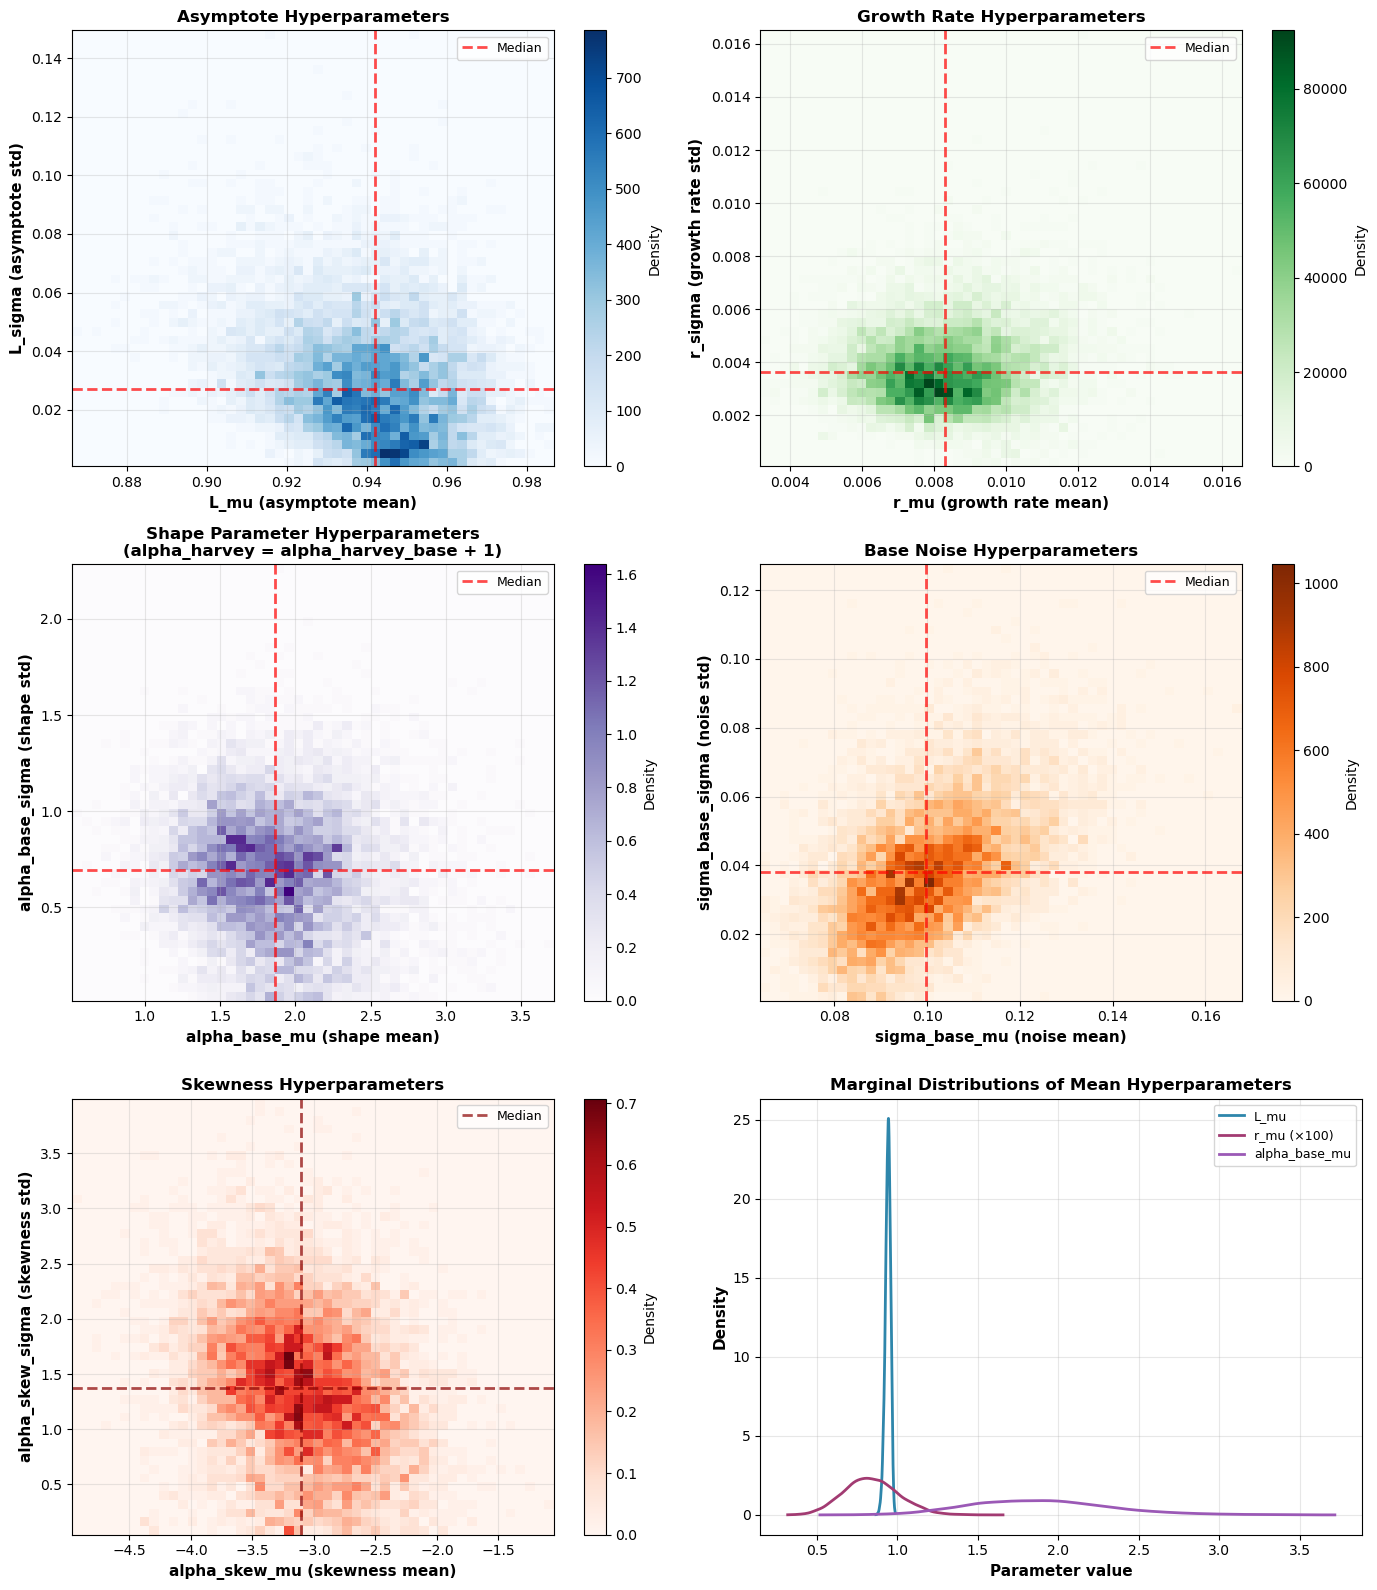


JOINT HARVEY HYPERPARAMETER SUMMARY
Number of benchmarks: 6

Asymptote (L):
  L_mu: 0.942 [0.905, 0.970]
  L_sigma: 0.027 [0.003, 0.078]

Growth rate (r):
  r_mu: 0.0083 [0.0053, 0.0118]
  r_sigma: 0.0037 [0.0014, 0.0074]

Shape parameter (alpha_harvey_base, then +1 for Harvey):
  alpha_base_mu: 1.86 [1.12, 2.83]
  alpha_base_sigma: 0.69 [0.08, 1.36]
  → Implied alpha_harvey_mu: 2.86

Base noise (sigma_base):
  sigma_base_mu: 0.100 [0.076, 0.131]
  sigma_base_sigma: 0.038 [0.007, 0.081]

Skewness (alpha_skew):
  alpha_skew_mu: -3.10 [-4.05, -2.13]
  alpha_skew_sigma: 1.37 [0.19, 2.74]

TASK-SPECIFIC PARAMETER RANGES

Upper asymptotes (L) across tasks:
  Min: 0.923
  Median: 0.947
  Max: 0.954

Growth rates (r) across tasks:
  Min: 0.0048
  Median: 0.0088
  Max: 0.0133

Shape parameters (alpha_harvey) across tasks:
  Min: 2.25
  Median: 2.96
  Max: 3.80

Note: alpha=2 corresponds to logistic growth
      alpha>2 gives slower initial growth
      alpha<2 (but >1) gives faster initial gr

In [16]:
# ============================================================================
# EXECUTION: Fit joint model to all internal benchmarks
# ============================================================================

# Select benchmarks with sufficient data
benchmark_dict = {}
for task_name, data in internal_matrices.items():
    df_long = data['df_long']
    if len(df_long) >= 3:  # Minimum observations
        benchmark_dict[task_name] = df_long

print(f"Fitting joint Harvey model with {len(benchmark_dict)} internal benchmarks")

# Fit joint Harvey model
idata_joint, frontier_dfs, model_joint = fit_harvey_joint_hyperparameters(
    benchmark_dict,
    n_samples=2000,
    n_tune=1000,
    top_n=3,
    forecast_type="harvey_joint_hyperparameters_internalOnly",
    lower_bounds_dict=lower_bounds_dict
)

# Plot learned hyperparameters
plot_joint_hyperparameters(idata_joint, list(benchmark_dict.keys()))

# Print MCMC diagnostics for Harvey-specific parameters
print("\nJoint Harvey Model MCMC Diagnostics:")
print(az.summary(idata_joint, var_names=['L_mu', 'L_sigma', 'r_mu', 'r_sigma',
                                          'alpha_base_mu', 'alpha_base_sigma',
                                          'sigma_base_mu', 'sigma_base_sigma',
                                          'alpha_skew_mu', 'alpha_skew_sigma']))


Plotting: bench.task.frontiermath.frontiermath_2025_02_28_private
Saved plot to: Images/bench_task_frontiermath_frontiermath_2025_02_28_private_harvey_joint_top3_forecast.png


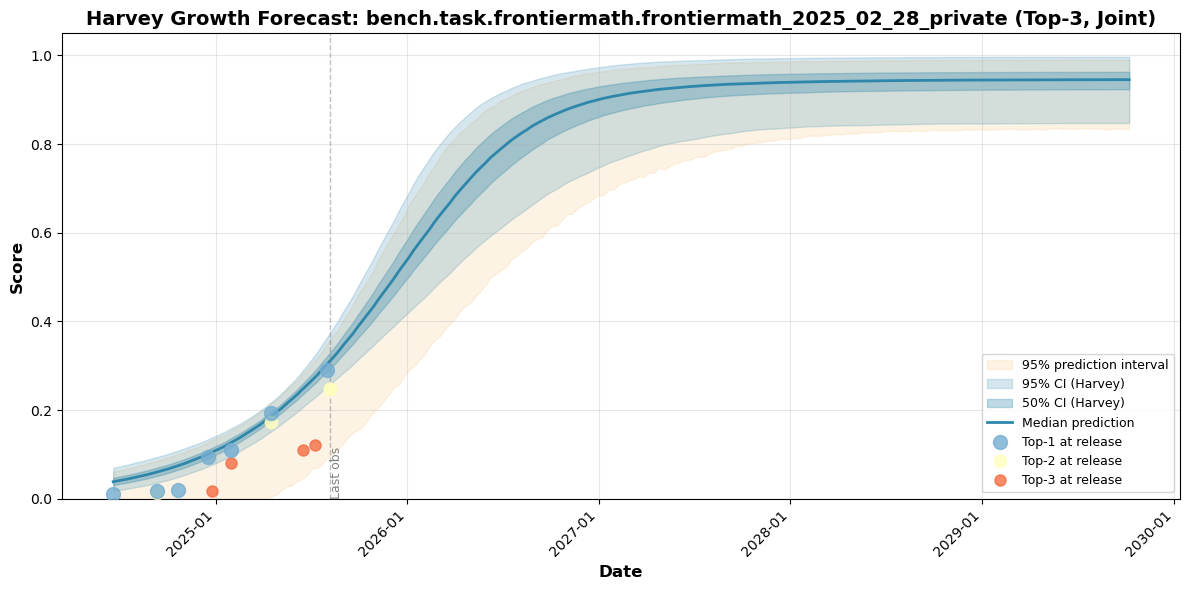


HARVEY FORECAST SUMMARY: bench.task.frontiermath.frontiermath_2025_02_28_private (Joint Model, Top-3)
Data points: 15
Unique models: 15
Lower asymptote (random chance): 0.000
Current best score: 0.290
Predicted upper asymptote (L): 0.946 [0.848, 0.997]
Growth rate (r): 0.0086 [0.0038, 0.0154]
Time offset (t0): 544 days
Shape parameter (α): 2.68 [1.34, 4.14]

Plotting: bench.task.frontiermath.frontiermath_tier_4_2025_07_01_private
Saved plot to: Images/bench_task_frontiermath_frontiermath_tier_4_2025_07_01_private_harvey_joint_top3_forecast.png


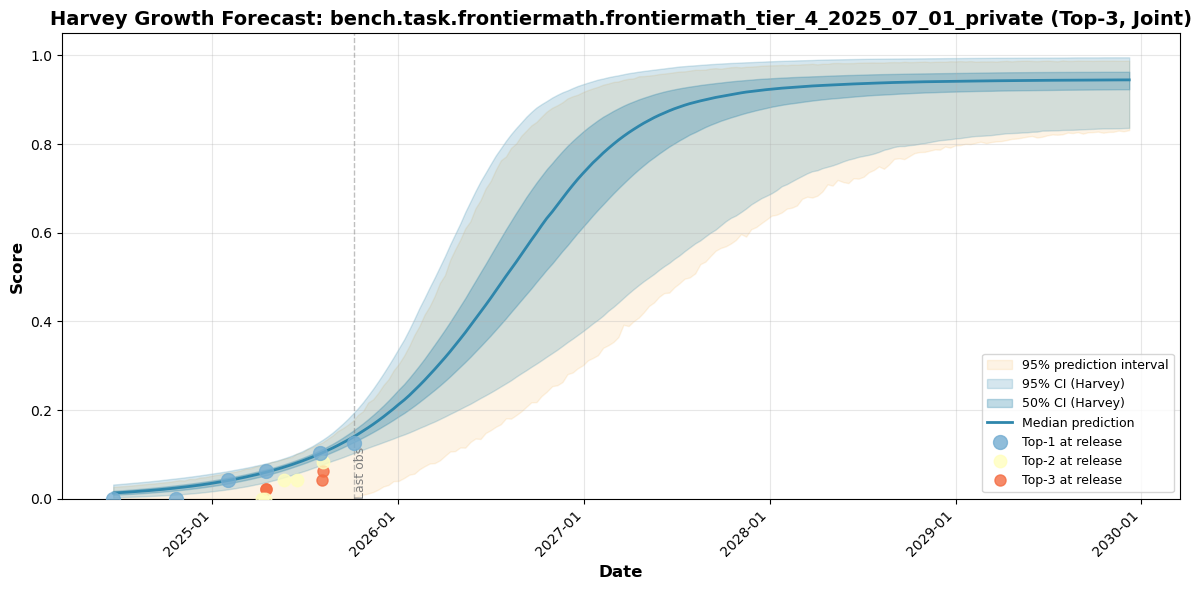


HARVEY FORECAST SUMMARY: bench.task.frontiermath.frontiermath_tier_4_2025_07_01_private (Joint Model, Top-3)
Data points: 15
Unique models: 15
Lower asymptote (random chance): 0.000
Current best score: 0.125
Predicted upper asymptote (L): 0.946 [0.847, 0.997]
Growth rate (r): 0.0089 [0.0038, 0.0168]
Time offset (t0): 784 days
Shape parameter (α): 2.78 [1.58, 4.26]

Plotting: bench.task.gpqa.gpqa_diamond
Saved plot to: Images/bench_task_gpqa_gpqa_diamond_harvey_joint_top3_forecast.png


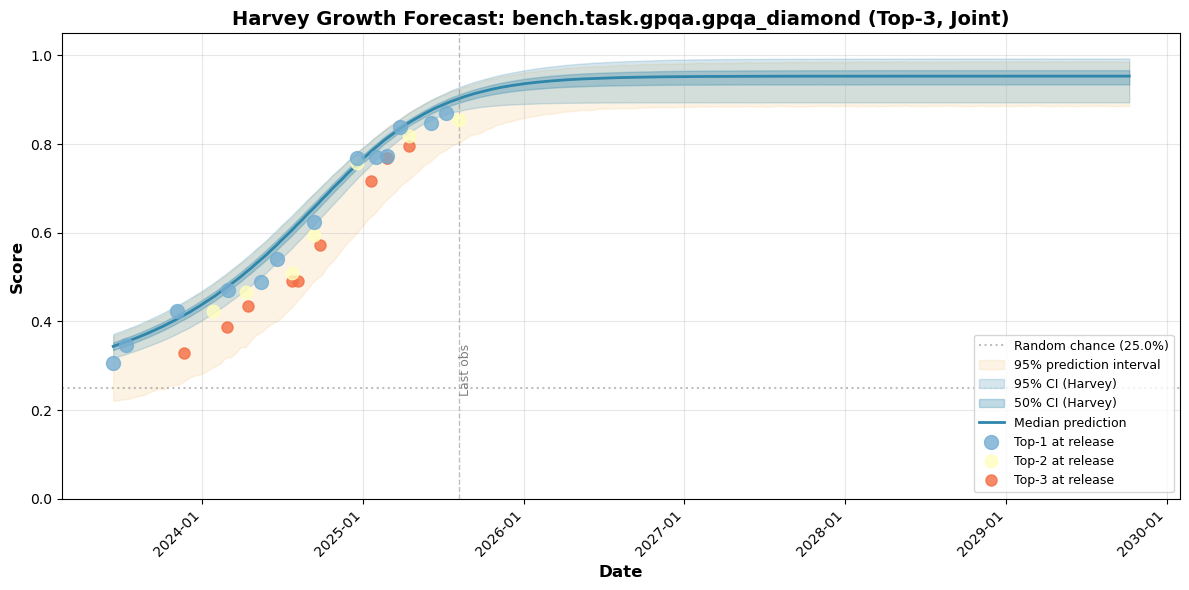


HARVEY FORECAST SUMMARY: bench.task.gpqa.gpqa_diamond (Joint Model, Top-3)
Data points: 30
Unique models: 30
Lower asymptote (random chance): 0.250
Current best score: 0.870
Predicted upper asymptote (L): 0.953 [0.894, 0.993]
Growth rate (r): 0.0082 [0.0060, 0.0123]
Time offset (t0): 469 days
Shape parameter (α): 3.34 [2.36, 5.04]

Plotting: bench.task.hendrycks_math.hendrycks_math_lvl_5
Saved plot to: Images/bench_task_hendrycks_math_hendrycks_math_lvl_5_harvey_joint_top3_forecast.png


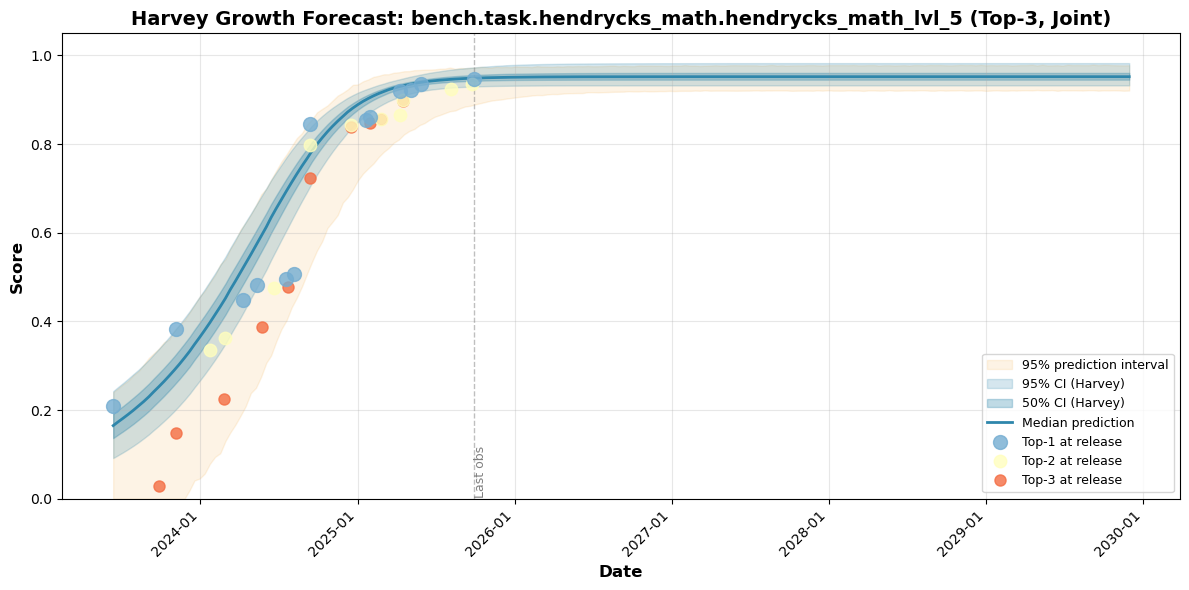


HARVEY FORECAST SUMMARY: bench.task.hendrycks_math.hendrycks_math_lvl_5 (Joint Model, Top-3)
Data points: 33
Unique models: 33
Lower asymptote (random chance): 0.000
Current best score: 0.947
Predicted upper asymptote (L): 0.952 [0.933, 0.983]
Growth rate (r): 0.0115 [0.0082, 0.0161]
Time offset (t0): 347 days
Shape parameter (α): 3.81 [2.57, 6.02]

Plotting: bench.task.otis_mock_aime.otis_mock_aime_24_25
Saved plot to: Images/bench_task_otis_mock_aime_otis_mock_aime_24_25_harvey_joint_top3_forecast.png


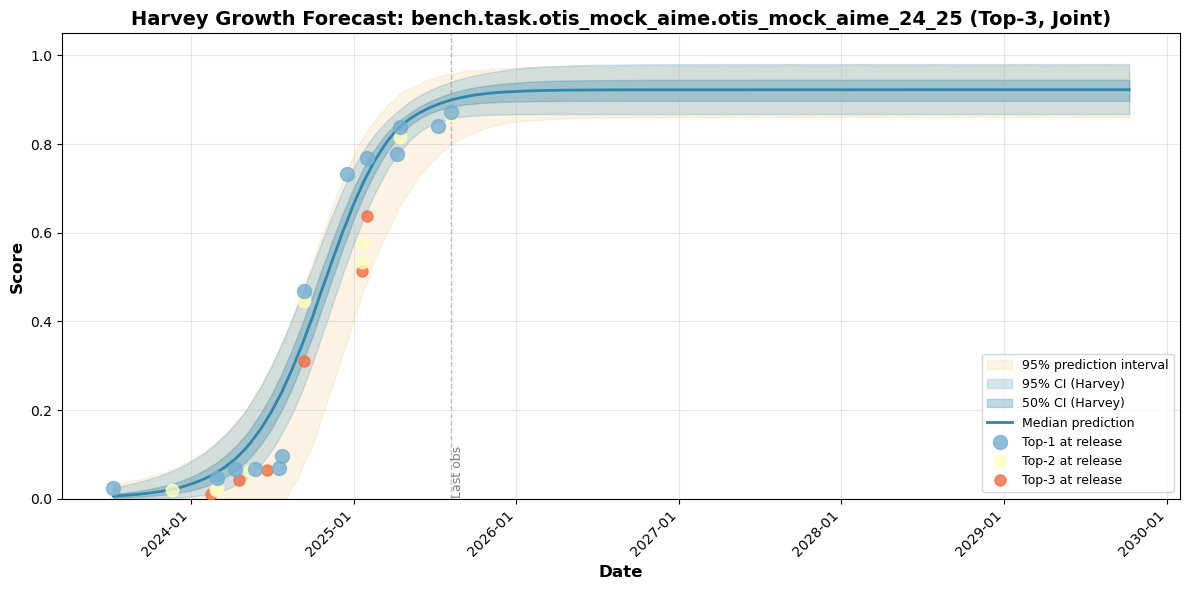


HARVEY FORECAST SUMMARY: bench.task.otis_mock_aime.otis_mock_aime_24_25 (Joint Model, Top-3)
Data points: 29
Unique models: 29
Lower asymptote (random chance): 0.001
Current best score: 0.872
Predicted upper asymptote (L): 0.923 [0.868, 0.981]
Growth rate (r): 0.0135 [0.0092, 0.0212]
Time offset (t0): 472 days
Shape parameter (α): 2.27 [1.39, 3.62]

Plotting: bench.task.swe_bench.swe_bench_verified
Saved plot to: Images/bench_task_swe_bench_swe_bench_verified_harvey_joint_top3_forecast.png


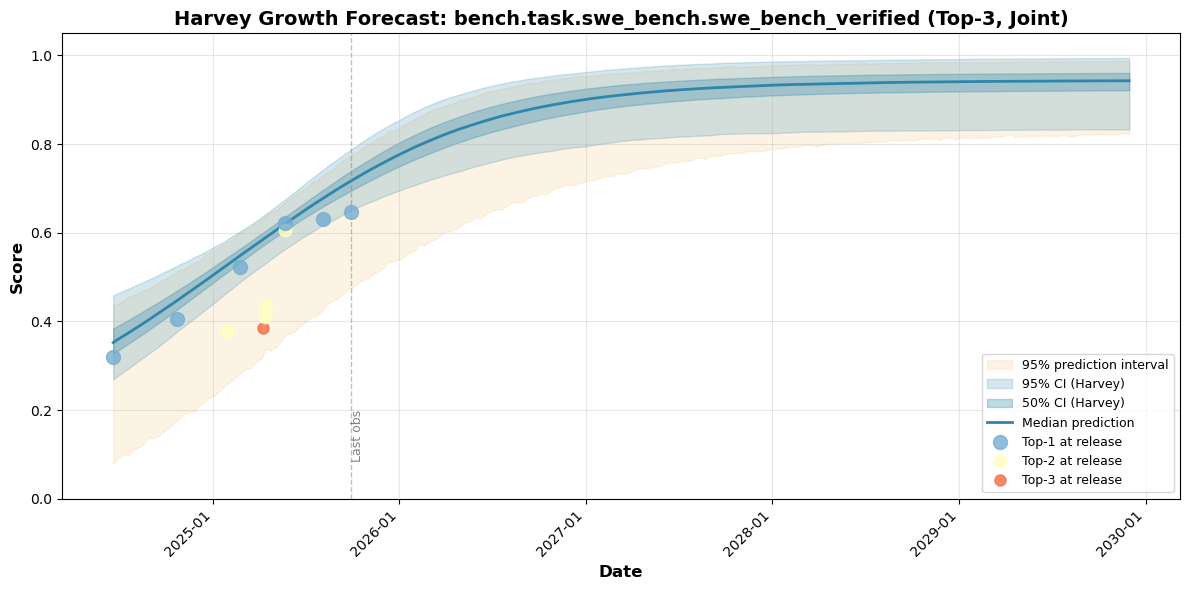


HARVEY FORECAST SUMMARY: bench.task.swe_bench.swe_bench_verified (Joint Model, Top-3)
Data points: 11
Unique models: 11
Lower asymptote (random chance): 0.000
Current best score: 0.648
Predicted upper asymptote (L): 0.945 [0.834, 0.997]
Growth rate (r): 0.0048 [0.0024, 0.0093]
Time offset (t0): 255 days
Shape parameter (α): 3.18 [1.64, 6.12]

Successfully fit joint model with 6 benchmarks


In [7]:
# ============================================================================
# PLOT FORECASTS FOR INDIVIDUAL BENCHMARKS
# ============================================================================

for task_idx, (task_name, frontier_df) in enumerate(frontier_dfs.items()):
    print(f"\nPlotting: {task_name}")
    
    # Get lower bound for this benchmark
    lower_bound = 0.0
    if lower_bounds_dict and task_name in lower_bounds_dict:
        lb = lower_bounds_dict[task_name]
        if not pd.isna(lb):
            lower_bound = lb
    
    plot_harvey_fit_from_joint(
        idata_joint, 
        frontier_df, 
        task_name, 
        task_idx,
        forecast_days=1523,
        top_n=3,
        forecast_type="harvey_joint",
        lower_bound=lower_bound
    )

print(f"\n{'='*80}")
print(f"Successfully fit joint model with {len(benchmark_dict)} benchmarks")
print(f"{'='*80}")

## All benchmarks

Fitting joint Harvey model with 41 benchmarks
  - Internal: 6
  - External: 35
  Lower bound for bench.task.frontiermath.frontiermath_2025_02_28_private: 0.0%
  Lower bound for bench.task.frontiermath.frontiermath_tier_4_2025_07_01_private: 0.0%
  Lower bound for bench.task.gpqa.gpqa_diamond: 25.0%
  Lower bound for bench.task.hendrycks_math.hendrycks_math_lvl_5: 0.0%
  Lower bound for bench.task.otis_mock_aime.otis_mock_aime_24_25: 0.1%
  Lower bound for bench.task.swe_bench.swe_bench_verified: 0.0%
  Lower bound for ARC AGI: 0.0%
  Lower bound for ARC AI2: 25.0%
  Lower bound for Adversarial NLI: 33.3%
  Lower bound for Aider polyglot: 0.0%
  Lower bound for BBH: 25.0%
  Lower bound for Balrog: 0.0%
  Lower bound for BoolQ: 50.0%
  Lower bound for CadEval: 0.0%
  Lower bound for CommonSenseQA 2: 50.0%
  Lower bound for Cybench: 0.0%
  Lower bound for DeepResearch Bench: NA (using 0.0)
  Lower bound for EnigmaEval: 0.0%
  Lower bound for Fiction.LiveBench: NA (using 0.0)
  Lower bound

Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [L_mu, L_sigma, r_mu, r_sigma, alpha_base_mu, alpha_base_sigma, sigma_base_mu, sigma_base_sigma, alpha_skew_mu, alpha_skew_sigma, L_raw, r, t0, alpha_harvey_base, sigma_base, alpha_skew]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 257 seconds.
There were 88 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Saved joint inference data to: Fits/joint_harvey_joint_hyperparameters_all_top3_idata.nc
Saved metadata to: Fits/joint_harvey_joint_hyperparameters_all_top3_metadata.pkl


/Users/jeremyandreolettigpaipolicylab/miniconda/envs/pymc_env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jeremyandreolettigpaipolicylab/miniconda/envs/pymc_env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jeremyandreolettigpaipolicylab/miniconda/envs/pymc_env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jeremyandreolettigpaipolicylab/miniconda/envs/pymc_env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2913: RuntimeWarning: divide by zero encountered in dot
  c = dot(X, X_T.conj())
/Users/jeremyandreolettigpaipolicylab/miniconda/envs/pymc_env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2913: RuntimeWarning: overflow encountered in dot
  c 

Saved hyperparameter plot to: Images/0_joint_harvey_hyperparameters.png


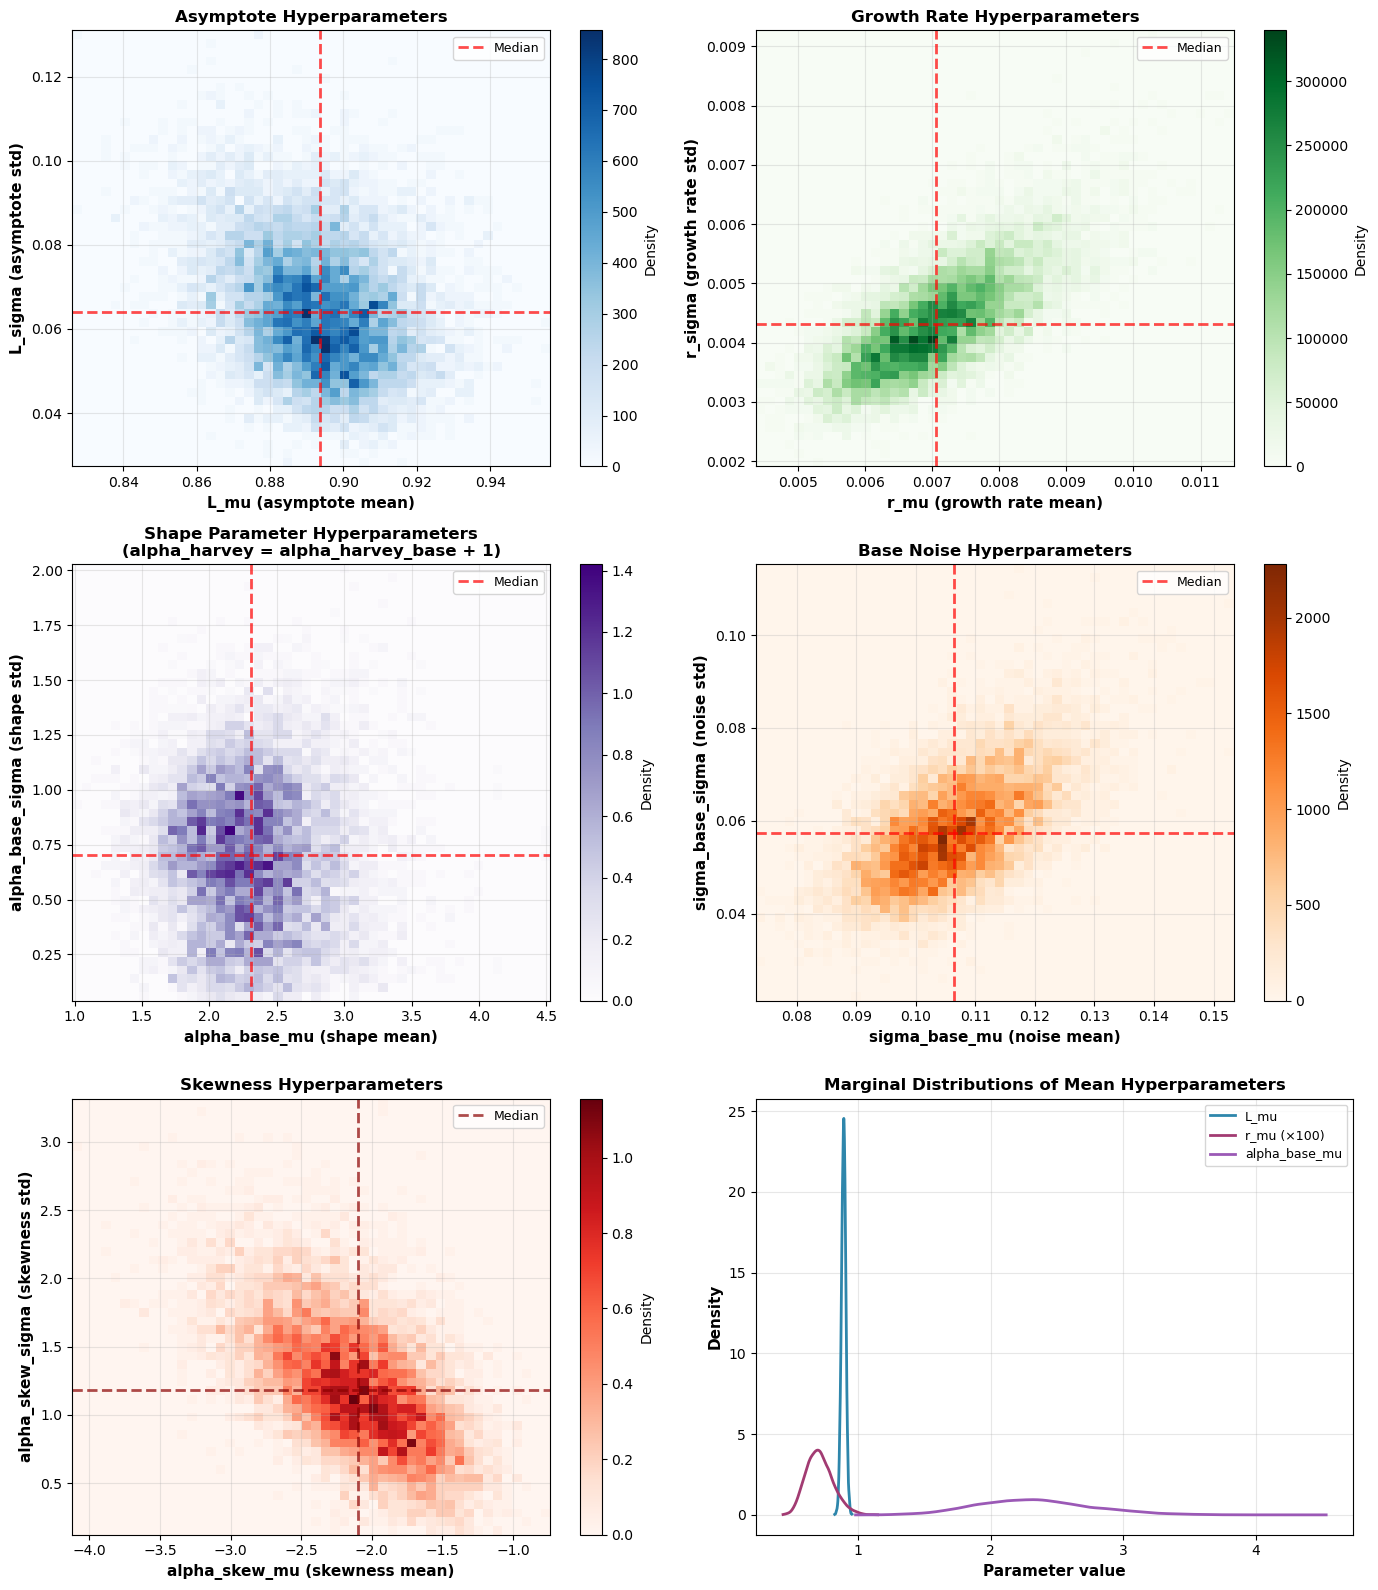


JOINT HARVEY HYPERPARAMETER SUMMARY
Number of benchmarks: 41

Asymptote (L):
  L_mu: 0.894 [0.860, 0.925]
  L_sigma: 0.064 [0.040, 0.099]

Growth rate (r):
  r_mu: 0.0071 [0.0054, 0.0093]
  r_sigma: 0.0043 [0.0030, 0.0064]

Shape parameter (alpha_harvey_base, then +1 for Harvey):
  alpha_base_mu: 2.31 [1.57, 3.25]
  alpha_base_sigma: 0.70 [0.12, 1.40]
  → Implied alpha_harvey_mu: 3.31

Base noise (sigma_base):
  sigma_base_mu: 0.106 [0.088, 0.129]
  sigma_base_sigma: 0.057 [0.039, 0.084]

Skewness (alpha_skew):
  alpha_skew_mu: -2.10 [-3.08, -1.30]
  alpha_skew_sigma: 1.18 [0.37, 2.25]

TASK-SPECIFIC PARAMETER RANGES

Upper asymptotes (L) across tasks:
  Min: 0.803
  Median: 0.906
  Max: 0.966

Growth rates (r) across tasks:
  Min: 0.0014
  Median: 0.0057
  Max: 0.0167

Shape parameters (alpha_harvey) across tasks:
  Min: 2.69
  Median: 3.30
  Max: 4.04

Note: alpha=2 corresponds to logistic growth
      alpha>2 gives slower initial growth
      alpha<2 (but >1) gives faster initial g

In [17]:
# ============================================================================
# EXECUTION: Fit joint model to ALL benchmarks (internal + external)
# ============================================================================

# Combine all benchmarks with sufficient data
benchmark_dict_all = {}

# Add internal benchmarks
for task_name, data in internal_matrices.items():
    df_long = data['df_long']
    if len(df_long) >= 3:  # Minimum observations
        benchmark_dict_all[task_name] = df_long

# Add external benchmarks
for task_name, data in external_matrices.items():
    df_long = data['df_long']
    if len(df_long) >= 3:  # Minimum observations
        benchmark_dict_all[task_name] = df_long

print(f"Fitting joint Harvey model with {len(benchmark_dict_all)} benchmarks")
print(f"  - Internal: {sum(1 for k in benchmark_dict_all if k in internal_matrices)}")
print(f"  - External: {sum(1 for k in benchmark_dict_all if k in external_matrices)}")

# Fit joint Harvey model
idata_joint_all, frontier_dfs_all, model_joint_all = fit_harvey_joint_hyperparameters(
    benchmark_dict_all,
    n_samples=2000,
    n_tune=1000,
    top_n=3,
    forecast_type="harvey_joint_hyperparameters_all",
    lower_bounds_dict=lower_bounds_dict
)

# Plot learned hyperparameters
plot_joint_hyperparameters(idata_joint_all, list(benchmark_dict_all.keys()))

# Print MCMC diagnostics for Harvey-specific parameters
print("\nJoint Harvey Model (All Benchmarks) MCMC Diagnostics:")
print(az.summary(idata_joint_all, var_names=['L_mu', 'L_sigma', 'r_mu', 'r_sigma',
                                              'alpha_base_mu', 'alpha_base_sigma',
                                              'sigma_base_mu', 'sigma_base_sigma',
                                              'alpha_skew_mu', 'alpha_skew_sigma']))

In [ ]:
# ============================================================================
# PLOT FORECASTS FOR INDIVIDUAL BENCHMARKS (ALL)
# ============================================================================

for task_idx, (task_name, frontier_df) in enumerate(frontier_dfs_all.items()):
    print(f"\nPlotting: {task_name}")
    
    # Get lower bound for this benchmark
    lower_bound = 0.0
    if lower_bounds_dict and task_name in lower_bounds_dict:
        lb = lower_bounds_dict[task_name]
        if not pd.isna(lb):
            lower_bound = lb
    
    plot_harvey_fit_from_joint(
        idata_joint_all, 
        frontier_df, 
        task_name, 
        task_idx,
        forecast_days=1523,
        top_n=3,
        forecast_type="harvey_joint_hyperparameters_all",
        lower_bound=lower_bound
    )

print(f"\n{'='*80}")
print(f"Successfully fit joint Harvey model with {len(benchmark_dict_all)} benchmarks")
print(f"  - Internal: {sum(1 for k in frontier_dfs_all if k in internal_matrices)}")
print(f"  - External: {sum(1 for k in frontier_dfs_all if k in external_matrices)}")
print(f"{'='*80}")

# Other

## Gamma distribution tests

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma  # Import gamma function from scipy

def gamma_params_from_mu_sigma(mu, sigma):
    """Convert from PyMC (mu, sigma) to (alpha, beta) parameterization"""
    alpha = (mu / sigma) ** 2
    beta = mu / (sigma ** 2)
    return alpha, beta

def gamma_pdf(x, mu, sigma):
    """Gamma PDF using PyMC parameterization"""
    alpha, beta = gamma_params_from_mu_sigma(mu, sigma)
    return (beta ** alpha) * (x ** (alpha - 1)) * np.exp(-beta * x) / gamma(alpha)

# Parameters
mu = 0.1
sigmas = [0.06, 0.07, 0.08]  # different standard deviations
x = np.linspace(0, 0.3, 1000)

# Create plot
plt.figure(figsize=(12, 6))

# Plot each distribution
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
for sigma, color in zip(sigmas, colors):
    plt.plot(x, gamma_pdf(x, mu, sigma), '-', 
             color=color, lw=2, 
             label=f'σ={sigma:.3f}')
    
    # Print implied parameters
    alpha, beta = gamma_params_from_mu_sigma(mu, sigma)
    print(f"σ={sigma:.3f}: α={alpha:.2f}, β={beta:.2f}")

# Add vertical line for mean
plt.axvline(mu, color='black', linestyle='--', alpha=0.5, label='Mean (μ)')

plt.xlabel('x')
plt.ylabel('Density')
plt.title(f'Gamma Distribution (PyMC parameterization) - Fixed μ={mu}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
alpha, beta = gamma_params_from_mu_sigma(mu, sigma)
print(f"Equivalent standard parameters: alpha={alpha:.2f}, beta={beta:.2f}")